In [1]:
!which python

/mnt/csc-gc8/work/afenteva/virtualenvs/jupyter/bin/python


In [2]:
!which pip

/mnt/csc-gc8/work/afenteva/virtualenvs/jupyter/bin/pip


In [3]:
import pandas as pd
import numpy as np
import scipy as sc
import pickle
import gzip
import re
import gseapy as gp
from math import factorial
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
%matplotlib inline

In [4]:
import scanpy as sc
import decoupler as dc
from anndata import AnnData

In [5]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [6]:
from scipy.stats import mannwhitneyu, ttest_ind
import conorm

In [7]:
pd.set_option('display.max_columns', 80)

In [8]:
sns.reset_defaults()
plt.rcParams['figure.facecolor'] = (1,1,1,1)
plt.rcParams['figure.dpi'] = 200
sns.set_style('white')

In [9]:
status_palette = {'Refractory': '#f28482',
                  'Responsive': '#81b29a'}

In [10]:
# Functions were adapted from https://github.com/BostonGene/Kassandra

def plot_colors(patches,
                ax=None,
                order='sort',
                w=0.25,
                h=0,
                legend_right=True,
                show_ticks=False):
    
    cur_patches = pd.Series(patches)

    if order == 'sort':
        order = list(np.sort(cur_patches.index))

    data = pd.Series([1] * len(order), index=order[::-1])
    if ax is None:
        if h == 0:
            h = 0.3 * len(patches)
        _, ax = plt.subplots(figsize=(w, h))

    data.plot(kind='barh',
              color=[cur_patches[x] for x in data.index],
              width=1,
              ax=ax)
    ax.set_xticks([])
    if legend_right:
        ax.yaxis.tick_right()

    sns.despine(offset={'left': -2}, ax=ax)

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    if not show_ticks:
        ax.tick_params(length=0)

    return ax

def bot_bar_plot(data,
                 palette=None,
                 lrot=0,
                 figsize=(5, 5),
                 title='',
                 ax=None,
                 order=None,
                 stars=False,
                 percent=False,
                 pvalue=False,
                 p_digits=5,
                 legend=True,
                 xl=True,
                 offset=-0.1,
                 linewidth=0,
                 align='center',
                 bar_width=0.9,
                 edgecolor=None,
                 hide_grid=True,
                 draw_horizontal=False,
                 plot_all_borders=True):

    from matplotlib.ticker import FuncFormatter

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    if pvalue:
        from scipy.stats import chi2_contingency

        chi2_test_data = chi2_contingency(data)
        p = chi2_test_data[1]
        if title is not False:
            title += '\n' + str(p)

    if percent:
        c_data = data.apply(lambda x: x * 1.0 / x.sum(), axis=1)
        if title:
            title = '% ' + title
        ax.set_ylim(0, 1)
    else:
        c_data = data

    c_data.columns = [str(x) for x in c_data.columns]

    if order is None:
        order = c_data.columns
    else:
        order = [str(x) for x in order]

    if palette is None:
        c_palette = lin_colors(pd.Series(order))

        if len(order) == 1:
            c_palette = {order[0]: blue_color}
    else:
        c_palette = {str(k): v for k, v in palette.items()}

    if edgecolor is not None:
        edgecolor = [edgecolor] * len(c_data)


    c_data[order].plot(kind='bar', stacked=True, position=offset, width=bar_width,
                       color=pd.Series(order).map(c_palette).values, ax=ax, linewidth=linewidth,
                       align=align, edgecolor=edgecolor)

    if legend:
        ax.legend(bbox_to_anchor=(1, 1), loc=2, borderaxespad=0.1)
    else:
        ax.legend_.remove()
        
    if percent:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

    return ax

# Files

In [11]:
path_to_samples_annotation = '/mnt/storageBig8/work/afenteda/RNASEQ/bulk/annotation_set1_set16.tsv'
path_to_patients_annotation = '/mnt/storageBig8/work/afenteda/ChemoRef/data/refractory/cohort_analysis_data_2023_05_04.xlsx'
path_to_clinical_data = '/mnt/storageBig8/work/afenteda/clinical_export/clinical_export_2023-10-04.csv'

# Load expr and annotations

In [12]:
ann_samples = pd.read_csv(path_to_samples_annotation,
                   sep='\t',
                   index_col=0)

In [14]:
counts = pd.read_csv('/mnt/storageBig8/work/afenteda/RNASEQ/bulk/counts_set1_14.tsv.gz',
                     sep='\t', index_col=0)

Z = pd.read_csv('/mnt/storageBig/resources/processed_data/HERCULES/rnaseq-decom/2023_03_10/out/Z.tsv.gz',
                     sep='\t', index_col=0)
Z = Z[[x for x in Z.columns if 'EOC' in x]]
Z.columns = [x.split('-"EOC"')[0] for x in Z.columns]

In [15]:
# non-normalized gene-level effective counts
counts.head(3)

,D327_oPlf1_RNA2,D327_p2Asc1_RNA1,D327_p2Ome1_RNA1,D327_p2OvaL1_RNA1,D327_p2OvaR1_RNA2,D328_p2Asc1_RNA1,D328_p2Ome1_RNA1,D328_p2OvaL1_RNA1,D328_p2Per1_RNA1,D329_pOme1_RNA1,D329_pOvaR1_RNA1,D329_pPer1_RNA1,D330_pAsc1_RNA1,D330_pOvaR1_RNA1,D331_iOme1_RNA1,D331_pAsc1_RNA1,D331_pOme1_RNA1,D331_pPer1_RNA1,D332_pAsc1_RNA1,D332_pOme1_RNA1,D332_pOvaL1_RNA1,D332_pOvaR1_RNA1,D332_pPer1_RNA1,D333_pMes1_RNA1,D333_pOvaL1_RNA1,D333_pPer1_RNA1,D334_pAsc1_RNA1,D334_pOvaL1_RNA1,D334_pPer1_RNA1,D335_iOme1_RNA1,D335_pAsc1_RNA1,D335_pOme1_RNA1,D336_iPer1_RNA1,D339_pLNL1_RNA1,D339_pMes1_RNA1,D339_pOvaL1_RNA1,D341_iAdnR1_RNA1,D341_iOme1_RNA1,D341_pAdnR1_RNA1,D341_pAsc1_RNA1,...,D376_pPer2_RNA1,D378_pMes1_RNA1,D378_pOme1_RNA1,D378_pPer1_RNA1,D381_pOme1_RNA1,D381_pOth1_RNA1,D381_pOvaR1_RNA1,D382_pAsc1_RNA1,D382_pOth1_RNA1,D382_pTub1_RNA1,D383_pMes1_RNA1,D383_pOme1_RNA1,D383_pOvaR1_RNA1,D384_pOth1_RNA1,D384_pOth2_RNA1,D384_pUte1_RNA1,D385_iMes1_RNA1,D387_pAdnL1_RNA1,D387_pAsc1_RNA1,D394_pOme1_RNA1,D394_pOvaR1_RNA1,D394_pPer1_RNA1,H067_r1Oth1_RNA1,H107_pMes1_RNA1,H213_p2Ome1_RNA1,H269_pOvaR1_RNA1,H276_r1PlfR1_RNA1,H326_pOth1_RNA1,H326_pOvaL1_RNA1,H326_pOvaL2_RNA1,D370_iOme2_RNA1,D370_iOvaL1_RNA1,D376_iOme1_RNA1,D380_pAdnR1_RNA1,D380_pLnr1_RNA1,D380_pPer1_RNA1,D380_pTubL1_RNA1,D382_iOme1_RNA1,D383_pOvaL1_RNA1,D387_pOvaL1_RNA1
ENSG00000000003.14,984.328195,639.114623,504.098573,1602.627034,1796.813567,794.800284,2831.043240,2095.699092,1367.930323,1700.592735,1937.712209,1456.120263,94.675006,7006.797561,416.558748,2856.106020,1589.403541,1863.288026,404.921384,4341.204162,8020.885415,1811.240348,4788.936448,848.976463,1676.049368,687.917429,150.977776,1820.829959,1022.064026,808.664268,2491.825487,1314.659435,1340.905136,716.688643,942.612311,203.483793,1901.004259,1506.992008,5200.871588,4642.231023,...,1205.875460,1701.866093,1888.657933,1956.939752,2246.972229,2570.529581,2071.007019,4021.464555,2286.893418,2417.978961,1813.893626,1678.749724,2545.026743,1487.170793,1995.202662,848.025870,973.431889,4141.526316,3354.297407,1475.037359,2544.570672,1110.175189,952.990381,2711.184171,1560.140862,1239.171472,4484.025084,1634.944519,2708.482735,4046.372715,538.015106,1026.115066,1534.512907,1711.229385,876.436161,929.840354,1017.303645,4021.517247,3616.394195,8254.062494
ENSG00000000005.5,2.186050,0.000000,20.063770,8.331166,12.745242,0.000000,0.000000,0.000000,3.769171,5.152326,0.000000,0.000000,0.000000,12.374033,109.023038,1.326685,368.492929,2.515315,0.000000,0.000000,0.000000,3.775096,1.400924,0.779728,40.297050,10.503571,0.000000,0.000000,2.451472,39.965669,0.000000,115.940361,0.000000,93.062763,0.000000,0.000000,3.750899,8.847803,1.247885,9.995154,...,3.033694,0.000000,0.000000,1.077021,4.388613,2.155543,2.243945,0.000000,0.000000,0.000000,11.972233,4.393940,0.000000,5.222846,2.170812,0.000000,0.000000,0.000000,0.000000,8.718948,0.000000,0.000000,0.000000,0.000000,49.388103,0.000000,1.287641,0.000000,0.000000,0.000000,0.000000,0.000000,60.379027,0.000000,0.000000,0.000000,0.000000,0.000000,2.605865,0.000000
ENSG00000000419.12,1299.336892,1161.809255,1086.085592,773.812956,637.300222,675.696273,1298.897496,735.074855,587.413826,1271.762222,998.580754,930.303665,585.706922,2380.710663,474.051478,1845.779319,833.752460,876.420477,588.631909,608.311431,887.271260,827.670975,846.808388,1234.279102,1021.687688,1027.759698,516.616992,865.010108,723.323866,585.379477,1377.957611,807.510381,621.475026,677.834387,800.659165,615.166651,1144.565922,579.194404,1425.713134,1915.530899,...,1244.267957,511.531941,675.962169,672.129109,686.130349,1018.699073,871.879647,707.853586,529.987805,474.601336,995.022914,943.139982,1230.072397,696.080633,774.433142,710.130745,984.707783,1061.374584,1591.145568,1178.286342,1786.663785,1133.473720,918.348024,1433.784290,657.920242,1064.031760,3029.566943,1510.695117,1028.135449,878.343313,693.742132,1467.412746,1604.846902,2419.877612,1898.752866,2508.542579,3045.017492,1117.317271,1712.561754,2343.721684


In [16]:
# non-normalized decomposed EOC gene-level read counts
Z.head(3)

,D327_oPlf1_RNA2,D327_p2Asc1_RNA1,D327_p2Ome1_RNA1,D327_p2OvaL1_RNA1,D327_p2OvaR1_RNA2,D328_p2Asc1_RNA1,D328_p2Ome1_RNA1,D328_p2OvaL1_RNA1,D328_p2Per1_RNA1,D329_pOme1_RNA1,D329_pOvaR1_RNA1,D329_pPer1_RNA1,D330_pAsc1_RNA1,D330_pOvaR1_RNA1,D331_iOme1_RNA1,D331_pAsc1_RNA1,D331_pOme1_RNA1,D331_pPer1_RNA1,D332_pAsc1_RNA1,D332_pOme1_RNA1,D332_pOvaL1_RNA1,D332_pOvaR1_RNA1,D332_pPer1_RNA1,D333_pMes1_RNA1,D333_pOvaL1_RNA1,D333_pPer1_RNA1,D334_pAsc1_RNA1,D334_pOvaL1_RNA1,D334_pPer1_RNA1,D335_iOme1_RNA1,D335_pAsc1_RNA1,D335_pOme1_RNA1,D336_iPer1_RNA1,D339_pLNL1_RNA1,D339_pMes1_RNA1,D339_pOvaL1_RNA1,D341_iAdnR1_RNA1,D341_iOme1_RNA1,D341_pAdnR1_RNA1,D341_pAsc1_RNA1,...,D376_pPer2_RNA1,D378_pMes1_RNA1,D378_pOme1_RNA1,D378_pPer1_RNA1,D381_pOme1_RNA1,D381_pOth1_RNA1,D381_pOvaR1_RNA1,D382_pAsc1_RNA1,D382_pOth1_RNA1,D382_pTub1_RNA1,D383_pMes1_RNA1,D383_pOme1_RNA1,D383_pOvaR1_RNA1,D384_pOth1_RNA1,D384_pOth2_RNA1,D384_pUte1_RNA1,D385_iMes1_RNA1,D387_pAdnL1_RNA1,D387_pAsc1_RNA1,D394_pOme1_RNA1,D394_pOvaR1_RNA1,D394_pPer1_RNA1,H067_r1Oth1_RNA1,H107_pMes1_RNA1,H213_p2Ome1_RNA1,H269_pOvaR1_RNA1,H276_r1PlfR1_RNA1,H326_pOth1_RNA1,H326_pOvaL1_RNA1,H326_pOvaL2_RNA1,D370_iOme2_RNA1,D370_iOvaL1_RNA1,D376_iOme1_RNA1,D380_pAdnR1_RNA1,D380_pLnr1_RNA1,D380_pPer1_RNA1,D380_pTubL1_RNA1,D382_iOme1_RNA1,D383_pOvaL1_RNA1,D387_pOvaL1_RNA1
ENSG00000000003.14,979.931480,628.567815,473.668365,1455.333881,1704.380052,636.861674,2553.293964,1883.781242,820.036919,1592.860851,1887.352067,1318.098772,59.841188,6748.195504,247.057525,2703.508467,1276.055014,1803.474588,341.347508,3836.967201,7166.993508,1690.840767,4389.172694,691.881389,1164.235940,564.199605,106.517291,1763.854986,875.774703,700.116974,2442.533769,1063.856067,1157.282722,435.036060,824.607857,166.466158,1702.87651,1012.280108,4799.163746,4236.382535,...,1035.267571,1401.924867,1552.267098,1672.031846,2102.878638,2444.603358,1941.966819,3821.029950,1931.245673,2032.381227,1690.274796,1553.648850,2445.246593,1257.766445,1916.598238,730.884961,763.492888,3691.625736,2459.245095,1413.657726,2352.825728,988.738509,735.807263,2610.556882,1115.241398,1178.560296,4425.628013,1464.611467,2485.384349,3690.405205,374.923701,934.79044,1345.783209,1663.003732,747.538555,841.091973,943.210831,3862.273058,3462.853791,7730.800805
ENSG00000000005.5,0.145303,0.000000,1.157298,0.067265,0.053181,0.000000,0.000000,0.000000,0.050748,0.090393,0.000000,0.000000,0.000000,0.033496,0.158210,0.015548,0.221743,0.019732,0.000000,0.000000,0.000000,0.043976,0.005675,0.004720,0.229818,0.024897,0.000000,0.000000,0.005767,0.117490,0.000000,0.735673,0.000000,0.350620,0.000000,0.000000,0.00605,0.043059,0.034261,0.021413,...,0.026215,0.000000,0.000000,0.001081,0.012471,0.007063,0.004704,0.000000,0.000000,0.000000,0.006643,0.009485,0.000000,0.706214,0.018007,0.000000,0.000000,0.000000,0.000000,0.029241,0.000000,0.000000,0.000000,0.000000,0.383324,0.000000,0.003319,0.000000,0.000000,0.000000,0.000000,0.00000,0.119933,0.000000,0.000000,0.000000,0.000000,0.000000,0.005977,0.000000
ENSG00000000419.12,1232.143398,1036.777259,943.749283,528.968841,472.642596,351.277482,1137.934255,660.971692,455.329510,1057.953501,903.880517,740.440918,237.485216,2165.896621,284.429582,1677.620054,515.699531,794.412455,255.100344,468.754346,756.652442,745.569765,686.518795,987.420452,653.196228,826.103489,208.465176,749.988526,575.414859,427.171993,1230.728010,544.231323,448.597005,388.753271,606.043496,489.120592,938.46655,344.339485,1245.945262,1528.780718,...,955.056644,353.459474,430.581267,456.043076,540.069488,868.132824,734.476749,632.898228,413.423915,305.703450,866.889393,809.658989,1065.161314,541.190513,673.598709,577.433890,541.587286,862.025805,1027.663906,1024.639654,1510.344218,859.664740,617.844779,1233.932849,420.106987,965.502105,2796.072869,1247.133800,915.921066,794.020159,445.665938,1250.90071,1011.990707,2291.614913,1629.451372,2285.748052,2800.757183,1012.569241,1582.732237,1972.290064


In [17]:
gene_dict = pd.read_csv('/mnt/storageBig8/work/afenteda/annotations/genes_reference_annotation.tsv',
                     sep='\t', index_col=0)
gene_dict.sample(3)

,geneName,geneType,uniqName
geneID,,,
ENSG00000250510.7,GPR162,protein_coding,GPR162
ENSG00000177963.13,RIC8A,protein_coding,RIC8A
ENSG00000145022.4,TCTA,protein_coding,TCTA


In [18]:
counts = counts.loc[gene_dict.index]
counts.index = gene_dict.loc[counts.index, 'geneName']

EOC = Z.loc[gene_dict.index]
EOC.index = gene_dict.loc[EOC.index, 'geneName']

In [19]:
# non-normalized EOC gene-level read counts
EOC.head(3)

,D327_oPlf1_RNA2,D327_p2Asc1_RNA1,D327_p2Ome1_RNA1,D327_p2OvaL1_RNA1,D327_p2OvaR1_RNA2,D328_p2Asc1_RNA1,D328_p2Ome1_RNA1,D328_p2OvaL1_RNA1,D328_p2Per1_RNA1,D329_pOme1_RNA1,D329_pOvaR1_RNA1,D329_pPer1_RNA1,D330_pAsc1_RNA1,D330_pOvaR1_RNA1,D331_iOme1_RNA1,D331_pAsc1_RNA1,D331_pOme1_RNA1,D331_pPer1_RNA1,D332_pAsc1_RNA1,D332_pOme1_RNA1,D332_pOvaL1_RNA1,D332_pOvaR1_RNA1,D332_pPer1_RNA1,D333_pMes1_RNA1,D333_pOvaL1_RNA1,D333_pPer1_RNA1,D334_pAsc1_RNA1,D334_pOvaL1_RNA1,D334_pPer1_RNA1,D335_iOme1_RNA1,D335_pAsc1_RNA1,D335_pOme1_RNA1,D336_iPer1_RNA1,D339_pLNL1_RNA1,D339_pMes1_RNA1,D339_pOvaL1_RNA1,D341_iAdnR1_RNA1,D341_iOme1_RNA1,D341_pAdnR1_RNA1,D341_pAsc1_RNA1,...,D376_pPer2_RNA1,D378_pMes1_RNA1,D378_pOme1_RNA1,D378_pPer1_RNA1,D381_pOme1_RNA1,D381_pOth1_RNA1,D381_pOvaR1_RNA1,D382_pAsc1_RNA1,D382_pOth1_RNA1,D382_pTub1_RNA1,D383_pMes1_RNA1,D383_pOme1_RNA1,D383_pOvaR1_RNA1,D384_pOth1_RNA1,D384_pOth2_RNA1,D384_pUte1_RNA1,D385_iMes1_RNA1,D387_pAdnL1_RNA1,D387_pAsc1_RNA1,D394_pOme1_RNA1,D394_pOvaR1_RNA1,D394_pPer1_RNA1,H067_r1Oth1_RNA1,H107_pMes1_RNA1,H213_p2Ome1_RNA1,H269_pOvaR1_RNA1,H276_r1PlfR1_RNA1,H326_pOth1_RNA1,H326_pOvaL1_RNA1,H326_pOvaL2_RNA1,D370_iOme2_RNA1,D370_iOvaL1_RNA1,D376_iOme1_RNA1,D380_pAdnR1_RNA1,D380_pLnr1_RNA1,D380_pPer1_RNA1,D380_pTubL1_RNA1,D382_iOme1_RNA1,D383_pOvaL1_RNA1,D387_pOvaL1_RNA1
geneName,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
OR4F5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.676533,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.110049,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.693742,0.000000,0.000000,0.000000
FO538757.2,0.000000,0.000000,0.000000,0.000000,0.000000,0.045423,0.000000,0.000000,0.028327,0.000000,0.000000,0.165799,0.000000,0.000000,0.00000,0.000000,0.000000,0.000202,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000003,0.687150,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0000,0.000000,1.278621,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000377,0.00000,0.000000,0.00000,0.000000,0.000000,5.124443,0.000000,0.00000,0.000000,0.000000,0.008377,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
FO538757.1,137.786965,118.028254,183.449086,222.510366,127.508107,83.576002,182.027649,123.209359,117.469758,489.287162,343.798696,522.456057,55.302251,356.404291,158.32021,700.572973,55.647412,271.418811,165.047112,180.175777,179.54654,204.913025,136.682492,199.446987,184.243858,168.229382,100.724961,272.933504,361.211636,191.385852,324.794475,197.423906,124.1999,234.239472,185.916189,338.890596,316.563922,91.993145,281.735197,398.95634,...,238.761069,230.494671,243.307971,149.413372,263.776105,128.814198,184.046798,95.202983,229.88699,73.792243,313.7644,194.613302,437.924672,140.549982,133.563861,161.648717,175.603325,45.128455,193.88074,407.057747,260.948675,276.70678,254.721603,57.95638,144.314704,340.636581,306.282915,297.264199,247.05144,389.000123,222.308615,429.970867,197.657067,514.134217,653.359983,404.384608,332.801332,273.458726,371.668612,192.918581


In [20]:
EOC.shape, counts.shape

((20361, 869), (20361, 869))

In [21]:
ann = pd.read_csv('/mnt/storageBig8/work/afenteda/ChemoRef/data/refractory/II_tissue/ann/ann_58_full.tsv',
                  sep='\t', index_col=0)

In [22]:
refractory_patients = list(ann[ann.Status == 'Refractory'].patient.unique())
responsive_patients = list(ann[ann.Status == 'Responsive'].patient.unique())
len(refractory_patients), len(responsive_patients)

(20, 38)

In [23]:
# TMM-normalized values

EOC_tmm = conorm.tmm(EOC)
bulk_tmm = conorm.tmm(counts)

In [24]:
ann.head(3)

,hash,set,new_name,comment,tissue,patient,phase,sample,WGS_data_name,EOC,purity_TP53AF,Status,Stratum_curated,Analysis_I,Analysis_II,group_tissue,Publication_code,RECIST_1_1_Response_to_NACT,Primary_therapy_outcome,PFI,Progression,PFS,Survival,FUT,dg_date,Histology,Stage_FIGO2014,Treatment_strategy,Age_at_Diagnosis,BMI_at_Dg,Any_debulking_surgery,Residual_tumor_IDS_inferred,Oper1_Omental_disease_largest_nodule_NEW,Oper2_Omental_disease_largest_nodule_NEW,CRS_Omental_clean_JO,ascites_1000ml_JO,Primary_chemotherapy_cycles,NACT_cycles,Post_IDS_chemotherapy_cycles,Maintenance_therary_after_1st_line,PARPi_treatment,Participation_in_clinical_trials,HR_causal_gene,SBS3,HRD_Clinical,operids2,date_refoper,date_endther,cadg,caids,caend,state,publication_code,stress_score,proliferation_score,plot_code,Identification
M054_pOme,1ab67bb8d,set2-6,M054_pOme,0.0,Ome,M054,Primary,M054_pOme,No_sample,0.665347,NaN,Refractory,refractory_IDS,in,in,Ome_group,EOC1023,Partial Response to NACT,Progressive Disease,17.0,1,203,1,527,15.3.2012,high grade serous,IIIC,NACT,57,22.68,IDS,0,over 5cm,less than 2cm,2.0,Yes,7,3.0,4.0,no,No,No,no_WGS_data,HRD,NaN,True,84.0,186.0,1205.0,32.0,66.0,ND,EOC1023,medium,medium,EOC1023_Ome,Tumor
M086_pPer,1abd78173,set2-6,M086_pPer,0.0,Per,M086,Primary,M086_pPer,M086_pPer1,0.702794,0.692,Responsive,Ctrl_responsive,in,in,Per_group,EOC868,Partial Response to NACT,Complete Response,285.0,1,467,1,871,6.3.2014,high grade serous,IIIC,NACT,62,29.36,IDS,0,over 5cm,No,2.0,Yes,6,3.0,3.0,bevacizumab,No,No,BRCA2,HRD,NaN,True,97.0,182.0,1565.0,36.0,8.0,evolving,EOC868,medium,medium,EOC868_Per,Tumor
M044_pOva,1546425d1,set2-6,M044_pOva,0.0,Ova,M044,Primary,M044_pOva,No_sample,0.714217,NaN,Refractory,refractory_IDS,in,in,Adn_group,EOC551,Stable Disease after NACT,Progressive Disease,19.0,1,181,1,802,24.11.2011,high grade serous,IVA,NACT,71,30.Dec,IDS,1 to 10mm,over 5cm,2 to 5cm,1.0,Yes,6,3.0,3.0,no,No,No,no_WGS_data,HRD,NaN,True,98.0,162.0,161.0,18.0,7.0,ND,EOC551,medium,medium,EOC551_Ova,Tumor


## Libraries

In [25]:
collectri = dc.get_collectri(organism='human', split_complexes=False)
progeny = dc.get_progeny(top=500)
msigdb = dc.get_resource('MSigDB')

In [26]:
# Filter by hallmark
PID = msigdb[msigdb.collection=='pid_pathways']

# Remove duplicated entries
PID = PID[~PID.duplicated(['geneset', 'genesymbol'])]

# Rename
PID.loc[:, 'geneset'] = [name.split('PID_')[1] for name in PID['geneset']]

PID.head(2)

/tmp/ipykernel_245587/511279014.py:8: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  PID.loc[:, 'geneset'] = [name.split('PID_')[1] for name in PID['geneset']]


,genesymbol,collection,geneset
333,FOSL2,pid_pathways,DELTA_NP63_PATHWAY
356,FOSL2,pid_pathways,AP1_PATHWAY


In [27]:
# Filter by hallmark
KEGG = msigdb[msigdb.collection=='kegg_pathways']

# Remove duplicated entries
KEGG = KEGG[~KEGG.duplicated(['geneset', 'genesymbol'])]

# Rename
KEGG.loc[:, 'geneset'] = [name.split('KEGG_')[1] for name in KEGG['geneset']]

KEGG.head(2)

/tmp/ipykernel_245587/952760805.py:8: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  KEGG.loc[:, 'geneset'] = [name.split('KEGG_')[1] for name in KEGG['geneset']]


,genesymbol,collection,geneset
230,ICOSLG,kegg_pathways,CELL_ADHESION_MOLECULES_CAMS
243,ICOSLG,kegg_pathways,INTESTINAL_IMMUNE_NETWORK_FOR_IGA_PRODUCTION


In [28]:
# Filter by hallmark
REACTOME = msigdb[msigdb['collection']=='reactome_pathways']

# Remove duplicated entries
REACTOME = REACTOME[~REACTOME.duplicated(['geneset', 'genesymbol'])]

# Rename
REACTOME.loc[:, 'geneset'] = [name.split('REACTOME_')[1] for name in REACTOME['geneset']]

REACTOME.head(2)

/tmp/ipykernel_245587/3692446534.py:8: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  REACTOME.loc[:, 'geneset'] = [name.split('REACTOME_')[1] for name in REACTOME['geneset']]


,genesymbol,collection,geneset
182,ICOSLG,reactome_pathways,COSTIMULATION_BY_THE_CD28_FAMILY
248,ICOSLG,reactome_pathways,ADAPTIVE_IMMUNE_SYSTEM


In [29]:
# Filter by hallmark
HALLMARK = msigdb[msigdb['collection']=='hallmark']

# Remove duplicated entries
HALLMARK = HALLMARK[~HALLMARK.duplicated(['geneset', 'genesymbol'])]

# Rename
HALLMARK.loc[:, 'geneset'] = [name.split('HALLMARK_')[1] for name in HALLMARK['geneset']]

HALLMARK.head(2)

/tmp/ipykernel_245587/187665752.py:8: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  HALLMARK.loc[:, 'geneset'] = [name.split('HALLMARK_')[1] for name in HALLMARK['geneset']]


,genesymbol,collection,geneset
11,MSC,hallmark,TNFA_SIGNALING_VIA_NFKB
149,ICOSLG,hallmark,TNFA_SIGNALING_VIA_NFKB


In [30]:
KEGG.shape, REACTOME.shape, HALLMARK.shape, PID.shape

((12697, 3), (87089, 3), (7318, 3), (8054, 3))

# Deconvolution

## Kassandra

In [31]:
preds = pd.read_csv('/mnt/storageBig8/work/afenteda/ChemoRef/results/refractory/Kassandra/Kassandra_predictions.tsv',
            sep='\t', index_col=0)

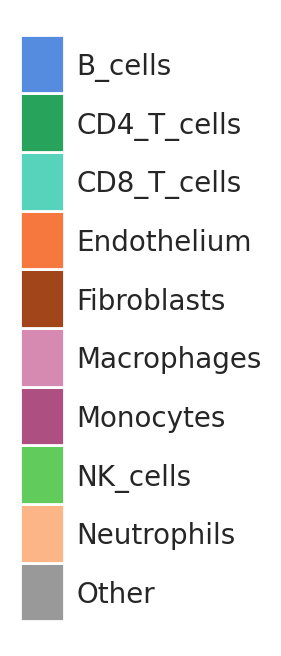

In [32]:
fig, axs = plt.subplots(1, 1, figsize=(0.3,4))

cells_p = { 'B_cells': '#558ce0',
            'CD4_T_cells': '#28a35c',
            'CD8_T_cells': '#58d3bb',
            'Endothelium': '#F6783E',
            'Fibroblasts': '#a3451a',
            'Macrophages': '#d689b1',
            'Monocytes': '#ad4f80',
            'NK_cells': '#61cc5b',
            'Neutrophils': '#FCB586',
            'Other': '#999999',
}

plot_colors(cells_p, ax=axs)
plt.show()

In [33]:
ann = ann.set_index('plot_code')
preds.columns = ann[ann['sample'].isin(preds.columns)].index

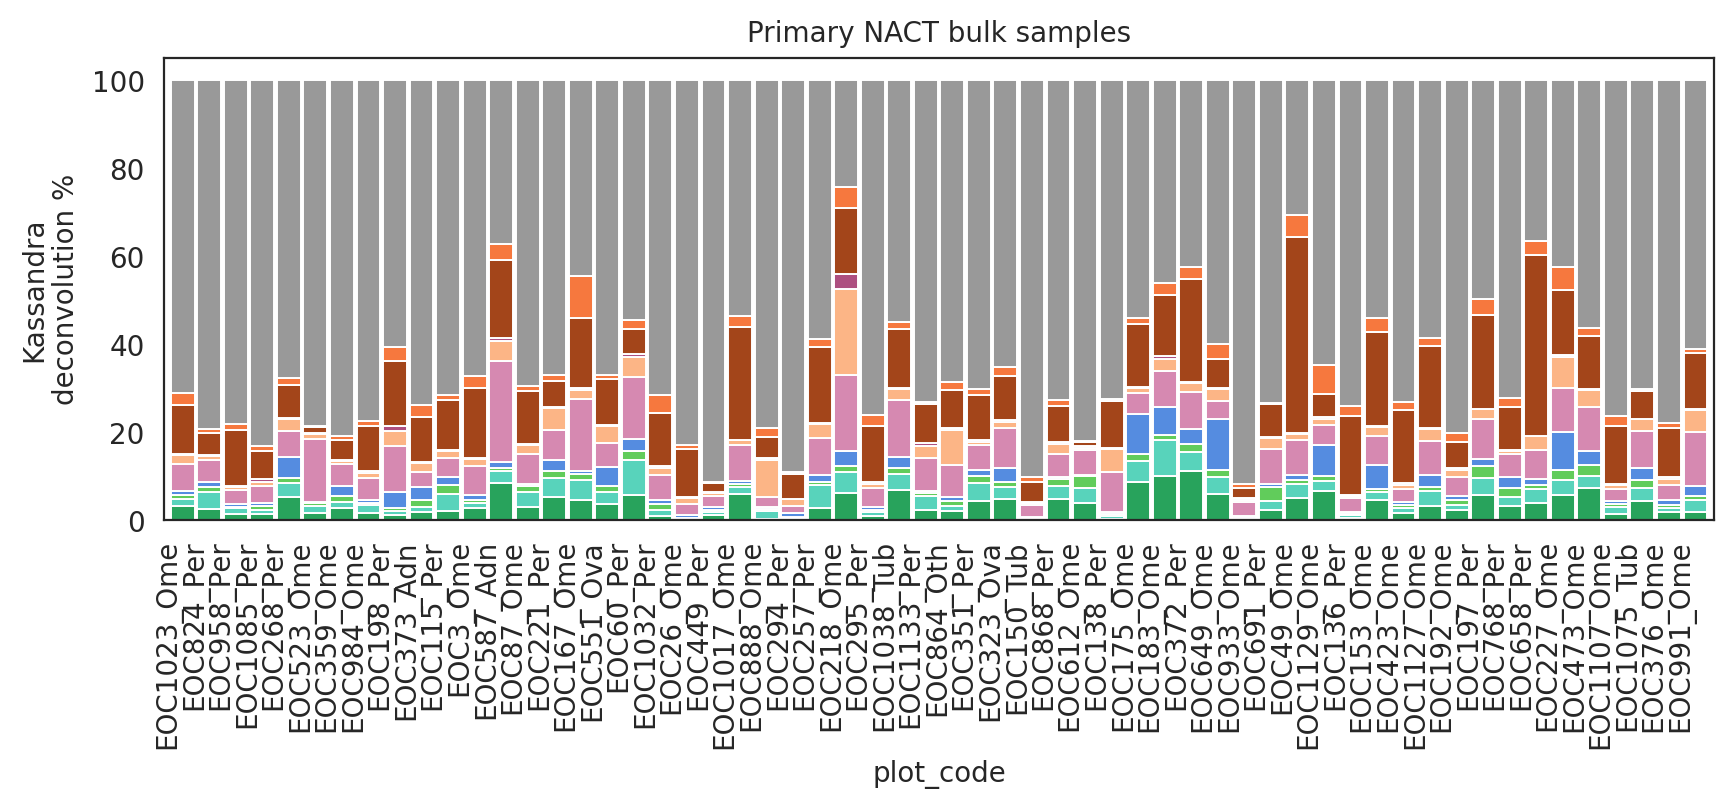

In [34]:
ax = bot_bar_plot(preds[ann.sort_values(by='Status').index].loc[['CD4_T_cells', 'CD8_T_cells',
                             'NK_cells', 'B_cells', 'Macrophages', 
                             'Neutrophils', 'Monocytes', 'Fibroblasts',
                             'Endothelium','Other', ]].T, palette=cells_p,
                  lrot=90, legend=False, xl=False,
                  linewidth=.7, figsize=(10,3))
ax.set_ylabel('Kassandra\ndeconvolution %')
ax.set_title('Primary NACT bulk samples', fontsize=10)
plt.show()

In [35]:
preds = preds.T
preds['Status'] = ann.loc[preds.index, 'Status']
preds.index.name = 'Sample'
preds['sample'] = preds.index
predsmelted=pd.melt(preds, id_vars=['sample', 'Status'], var_name='CellType_Abundance')

predsmelted = predsmelted[predsmelted.CellType_Abundance.isin(['CD4_T_cells', 'CD8_T_cells',
                             'NK_cells', 'B_cells', 'Macrophages_M1', 'Macrophages_M2', 
                             'Neutrophils', 'Monocytes',
                             'Endothelium', 'Fibroblasts', 'Other'])]

/tmp/ipykernel_245587/2953085665.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, rotation=-60)


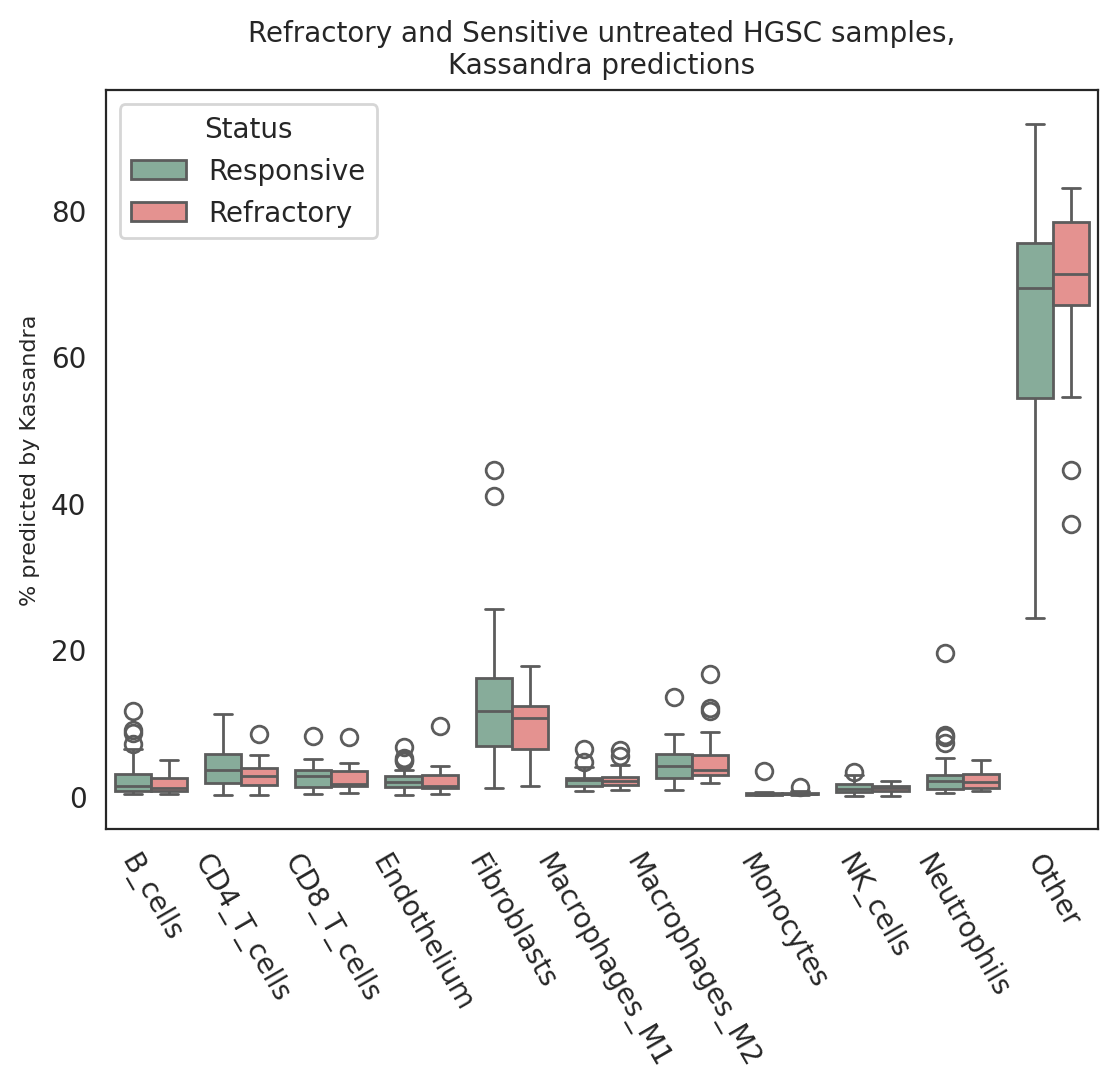

In [36]:
ax = sns.boxplot(data=predsmelted, x='CellType_Abundance', y='value', hue='Status',
                 palette=status_palette,
                 hue_order=['Responsive', 'Refractory']
                )
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, rotation=-60)

ax.set_ylabel('% predicted by Kassandra', fontsize=8)
ax.set_xlabel('', fontsize=0)
ax.set_title('Refractory and Sensitive untreated HGSC samples,\nKassandra predictions', fontsize=10)

plt.show()

In [37]:
preds.head(3)

,B_cells,CD4_T_cells,CD8_T_cells,CD8_T_cells_PD1_high,CD8_T_cells_PD1_low,Endothelium,Fibroblasts,Lymphocytes,Macrophages,Macrophages_M1,Macrophages_M2,Monocytes,NK_cells,Neutrophils,Non_plasma_B_cells,Other,Plasma_B_cells,T_cells,T_helpers,Tregs,Monocytic_cells,Stromal_cells,Status,sample
Sample,,,,,,,,,,,,,,,,,,,,,,,,
EOC1023_Ome,0.88,3.24,1.50,0.81,0.70,2.86,11.09,6.54,6.19,2.55,3.65,0.20,0.91,2.06,0.57,71.04,0.31,4.75,1.25,1.99,6.39,13.95,Refractory,EOC1023_Ome
EOC868_Per,0.36,4.78,2.95,1.93,1.02,1.36,8.15,9.81,5.31,2.51,2.80,0.40,1.72,2.26,0.29,72.70,0.07,7.73,1.90,2.88,5.71,9.51,Responsive,EOC868_Per
EOC551_Ova,4.28,3.62,2.68,1.65,1.03,0.93,10.48,12.08,5.47,2.28,3.19,0.24,1.50,3.76,3.71,67.04,0.58,6.30,1.25,2.37,5.71,11.41,Refractory,EOC551_Ova


In [40]:
# Even the nominal (without the correction for multiple hypothesis testing)
# p-values are not significant

for cell_type in preds.columns:
    if cell_type not in ['Status', 'sample']:
        print(cell_type,
              ttest_ind(preds[preds.Status == 'Responsive'][cell_type].values,
                        preds[preds.Status == 'Refractory'][cell_type].values))

B_cells Ttest_indResult(statistic=1.07295941068727, pvalue=0.28789131386952643)
CD4_T_cells Ttest_indResult(statistic=1.2090881565375498, pvalue=0.23170914398457218)
CD8_T_cells Ttest_indResult(statistic=0.12853406633472222, pvalue=0.8981868477722398)
CD8_T_cells_PD1_high Ttest_indResult(statistic=0.42554047105306086, pvalue=0.6720736933589859)
CD8_T_cells_PD1_low Ttest_indResult(statistic=-0.5441194086295427, pvalue=0.5885193081619443)
Endothelium Ttest_indResult(statistic=-0.15761386672778477, pvalue=0.8753280203241249)
Fibroblasts Ttest_indResult(statistic=1.3981982522889504, pvalue=0.16756683016662743)
Lymphocytes Ttest_indResult(statistic=1.0173776191070192, pvalue=0.3133492527273375)
Macrophages Ttest_indResult(statistic=-0.9166525799008903, pvalue=0.36325555197036896)
Macrophages_M1 Ttest_indResult(statistic=-0.5860158010943656, pvalue=0.5602195012654566)
Macrophages_M2 Ttest_indResult(statistic=-0.9703905141274797, pvalue=0.3360246341740891)
Monocytes Ttest_indResult(statistic=

## PRISM

In [42]:
# PRISM cell type abundancies
W = pd.read_csv('/mnt/storageBig/resources/processed_data/HERCULES/rnaseq-decom/2023_11_07/out/W.tsv.gz',
                sep='\t', index_col=0)
W = W.loc[ann['sample'].values]
W.index = ann[ann['sample'].isin(W.index)].index

W = W.loc[ann.index]
W['Status'] = ann.loc[W.index, 'Status']
W.index.name = 'Sample'
W['sample'] = W.index
Wmelted=pd.melt(W, id_vars=['sample', 'Status'], var_name='CellType_Abundance')

Wmelted = Wmelted[Wmelted.CellType_Abundance.isin(['EOC', 'Fibroblast', 'Immune', 'Unknown'])]

/tmp/ipykernel_245587/3781163536.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, rotation=-60)


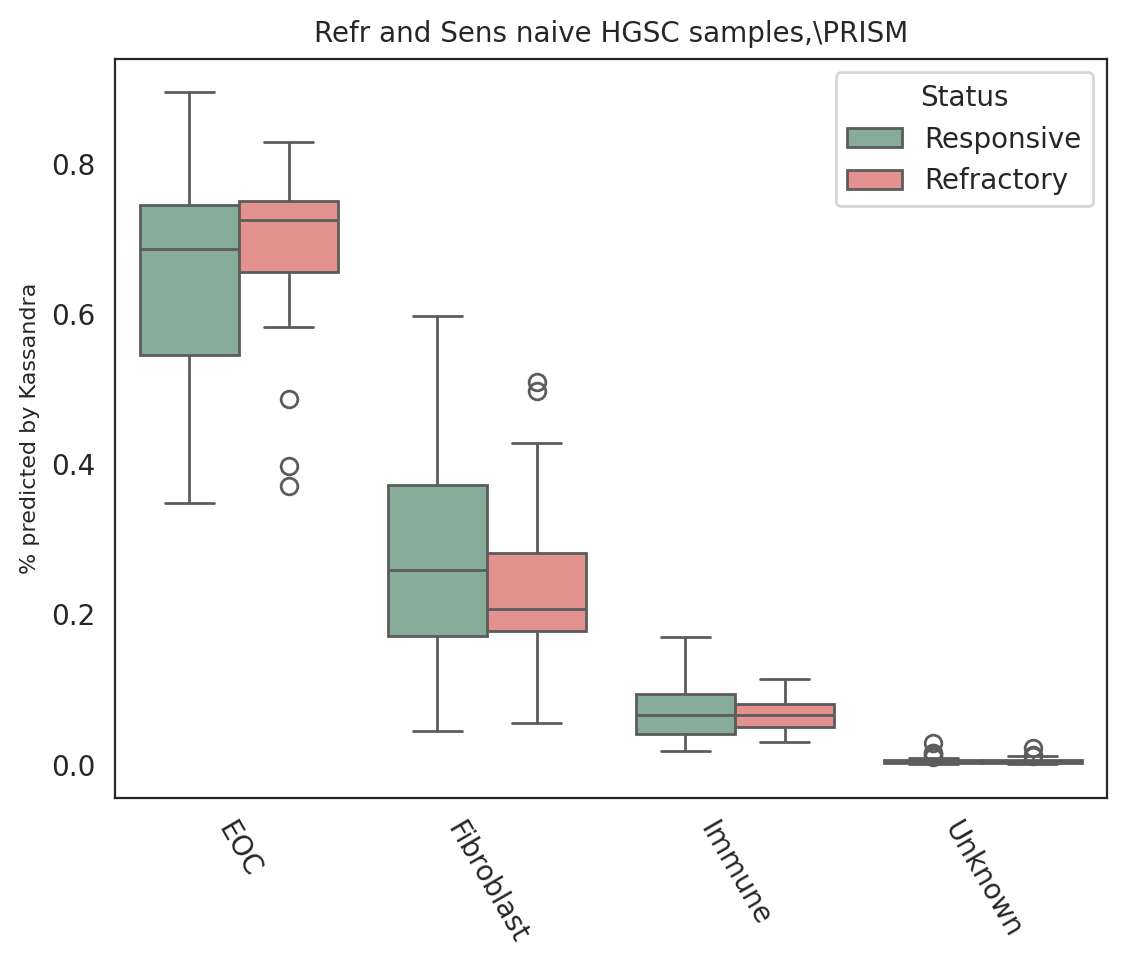

In [43]:
ax = sns.boxplot(data=Wmelted, x='CellType_Abundance', y='value', hue='Status',
                 palette=status_palette,
                 hue_order=['Responsive', 'Refractory']
                )
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, rotation=-60)

ax.set_ylabel('% predicted by Kassandra', fontsize=8)
ax.set_xlabel('', fontsize=0)
ax.set_title('Refr and Sens naive HGSC samples,\PRISM', fontsize=10)

plt.show()

In [44]:
# Even the nominal (without the correction for multiple hypothesis testing)
# p-values are not significant

ttest_ind(W[W.Status == 'Refractory']['EOC'].values, W[W.Status == 'Responsive']['EOC'].values)

Ttest_indResult(statistic=0.5821314096293085, pvalue=0.562814588959179)

In [45]:
# Even the nominal (without the correction for multiple hypothesis testing)
# p-values are not significant

ttest_ind(W[W.Status == 'Refractory']['Fibroblast'].values, W[W.Status == 'Responsive']['Fibroblast'].values)

Ttest_indResult(statistic=-0.5373480796113153, pvalue=0.5931560903362564)

In [46]:
# Even the nominal (without the correction for multiple hypothesis testing)
# p-values are not significant

ttest_ind(W[W.Status == 'Refractory']['Immune'].values, W[W.Status == 'Responsive']['Immune'].values)

Ttest_indResult(statistic=-0.2994890871035362, pvalue=0.7656756655940831)

## TCGA subtypes

In [47]:
subtypes = pd.read_csv('/mnt/storageBig8/work/afenteda/RNASEQ/TCGA_subtypes_set1-16.tsv',
                       sep=',', index_col=0)

In [48]:
subtypes = subtypes.loc[ann['sample'].values]
subtypes.index = ann[ann['sample'].isin(subtypes.index)].index
subtypes.head(3)

,consensusOV.subtypes,rf.probs.IMR_consensus,rf.probs.DIF_consensus,rf.probs.PRO_consensus,rf.probs.MES_consensus
plot_code,,,,,
EOC1023_Ome,MES_consensus,0.146,0.208,0.156,0.490
EOC868_Per,DIF_consensus,0.194,0.684,0.054,0.068
EOC551_Ova,PRO_consensus,0.240,0.216,0.398,0.146


In [49]:
ann = ann.join(subtypes.loc[ann.index][['consensusOV.subtypes']])

In [50]:
ann.groupby('Status')['consensusOV.subtypes'].value_counts()

Status      consensusOV.subtypes
Refractory  DIF_consensus            6
            MES_consensus            6
            PRO_consensus            6
            IMR_consensus            2
Responsive  MES_consensus           19
            IMR_consensus            8
            DIF_consensus            6
            PRO_consensus            5
Name: consensusOV.subtypes, dtype: int64

# DecoupleR

## DeSeq2 (DEA: Refractory vs Sensitive/Responsive)

In [51]:
EOC_study = EOC[ann['sample'].values]
EOC_study.columns = ann[ann['sample'].isin(EOC_study.columns)].index
EOC_study.head(3)

plot_code,EOC1023_Ome,EOC868_Per,EOC551_Ova,EOC60_Per,EOC1133_Per,EOC26_Ome,EOC218_Ome,EOC1032_Per,EOC167_Ome,EOC183_Ome,EOC376_Ome,EOC1129_Ome,EOC372_Per,EOC423_Ome,EOC87_Ome,EOC295_Per,EOC587_Adn,EOC649_Ome,EOC933_Ome,EOC691_Per,EOC49_Ome,EOC3_Ome,EOC136_Per,EOC153_Ome,EOC1127_Ome,EOC115_Per,EOC192_Ome,EOC197_Per,EOC991_Ome,EOC658_Per,EOC227_Ome,EOC473_Ome,EOC1107_Ome,EOC1075_Tub,EOC373_Adn,EOC198_Per,EOC175_Ome,EOC612_Ome,EOC449_Per,EOC1017_Ome,EOC888_Ome,EOC294_Per,EOC257_Per,EOC984_Ome,EOC359_Ome,EOC523_Ome,EOC138_Per,EOC1038_Tub,EOC268_Per,EOC864_Oth,EOC351_Per,EOC323_Ova,EOC1085_Per,EOC958_Per,EOC150_Tub,EOC824_Per,EOC768_Per,EOC221_Per
geneName,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
OR4F5,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.053681,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
FO538757.2,0.000000,0.000000,0.000000,0.000000,0.00000,0.033841,0.000001,0.000000,0.000000,0.000000,0.065502,0.231109,0.197836,0.00000,0.000000,0.000000,0.000000,0.000000,0.000001,1.415163,0.001251,0.001143,0.000000,0.001437,0.018237,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007299,0.63842,0.000000,0.000000,0.000138,0.699633,0.000000,0.000202,0.000000,0.000000,5.603891e-07,0.224339,0.000000,0.000000,0.000000,0.406058,0.000000,0.000000,0.000000,0.000000,2.881737,0.000000,0.000000,0.000000,0.000000,0.000000,0.000057
FO538757.1,400.680374,522.598615,459.327441,396.767891,504.19781,694.373747,320.448395,487.080023,586.003515,313.735874,599.369427,513.613648,411.892608,220.50946,155.926368,409.612156,159.050906,735.497241,1095.154447,709.783403,90.897592,618.902316,211.620097,909.248267,717.947035,431.891681,259.379142,391.773365,453.893004,283.450703,458.891139,360.024590,872.04605,103.448002,314.721733,152.838901,179.409133,156.028845,271.418811,197.423906,175.202146,3.954338e+02,314.067222,149.494542,484.386028,223.461979,309.955968,485.997752,514.262719,485.439896,335.063924,322.756925,294.154945,511.792402,160.197214,92.087861,98.144181,144.985255


In [52]:
# Transform to AnnData object

adata = AnnData(np.round(EOC_study[ann.index].T), dtype=np.float32)
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 58 × 20361

In [53]:
# Process treatment information
adata.obs['condition'] = [ann.loc[sample_id, 'Status'] for sample_id in adata.obs.index]
adata.obs['patient'] = [ann.loc[sample_id, 'patient'] for sample_id in adata.obs.index]
adata.obs['tissue'] = [ann.loc[sample_id, 'tissue'] for sample_id in adata.obs.index]
adata.obs['HRD'] = [ann.loc[sample_id, 'SBS3'] for sample_id in adata.obs.index]

# Process sample information
adata.obs['sample_id'] = adata.obs.index

In [54]:
# Obtain genes that pass the thresholds
genes = dc.filter_by_expr(adata, group='condition',
                          min_count=10, min_total_count=15, large_n=1, min_prop=1)

# Filter by these genes
adata = adata[:, genes].copy()
adata

AnnData object with n_obs × n_vars = 58 × 14709
    obs: 'condition', 'patient', 'tissue', 'HRD', 'sample_id'

In [55]:
# Build the DESeq2 object
dds = DeseqDataSet(
    adata=adata,
    design_factors=['HRD', 'condition'],
    # design_factors=['condition'],
    refit_cooks=True,
    ref_level = ['condition', 'Responsive']
)

In [56]:
# Compute LFCs
dds.deseq2()

Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 2.26 seconds.

Fitting dispersion trend curve...
... done in 0.48 seconds.

Fitting MAP dispersions...
... done in 2.36 seconds.

Fitting LFCs...
... done in 1.30 seconds.

Refitting 348 outliers.

Fitting dispersions...
... done in 0.12 seconds.

Fitting MAP dispersions...
... done in 0.13 seconds.

Fitting LFCs...
... done in 0.15 seconds.



In [57]:
G = pd.read_csv('/mnt/storageBig/resources/processed_data/HERCULES/rnaseq-decom/2023_03_10/out/G.tsv.gz',
                sep='\t', index_col=0)
W = pd.read_csv('/mnt/storageBig/resources/processed_data/HERCULES/rnaseq-decom/2023_03_10/out/W.tsv.gz',
                sep='\t', index_col=0)

nf_bulk = G.loc['bulk_gains']*W['EOC']
nf_bulk = nf_bulk / np.exp(np.mean(np.log(nf_bulk)))


nf_bulk_II = nf_bulk.loc[ann['sample'].values]
nf_bulk_II.index = ann[ann['sample'].isin(nf_bulk_II.index)].index
dds.obsm['size_factors'] = nf_bulk_II.values

In [58]:
stat_res = DeseqStats(dds,
                      contrast=["condition",
                                'Refractory',
                                'Responsive'])

In [59]:
# Compute Wald test
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: condition Refractory vs Responsive
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
geneName                                                                
FO538757.1   371.719696       -0.027642  0.202462 -0.136531  0.891401   
SAMD11       278.853394        0.167304  0.505277  0.331114  0.740559   
NOC2L       1594.377319       -0.042228  0.183180 -0.230529  0.817680   
KLHL17       157.060883       -0.215502  0.212579 -1.013751  0.310701   
PLEKHN1       29.591730        0.420490  0.291572  1.442149  0.149260   
...                 ...             ...       ...       ...       ...   
MT-ND4L     1853.098511        0.254824  0.333273  0.764609  0.444505   
MT-ND4      4746.125488        0.473570  0.342480  1.382768  0.166736   
MT-ND5      2139.694824        0.564986  0.303540  1.861323  0.062699   
MT-ND6       245.550308       -0.053156  0.260747 -0.203862  0.838461   
MT-CYB      3669.160400        0.613700  0.317313  

... done in 1.00 seconds.



In [60]:
# Extract results
results_df = stat_res.results_df

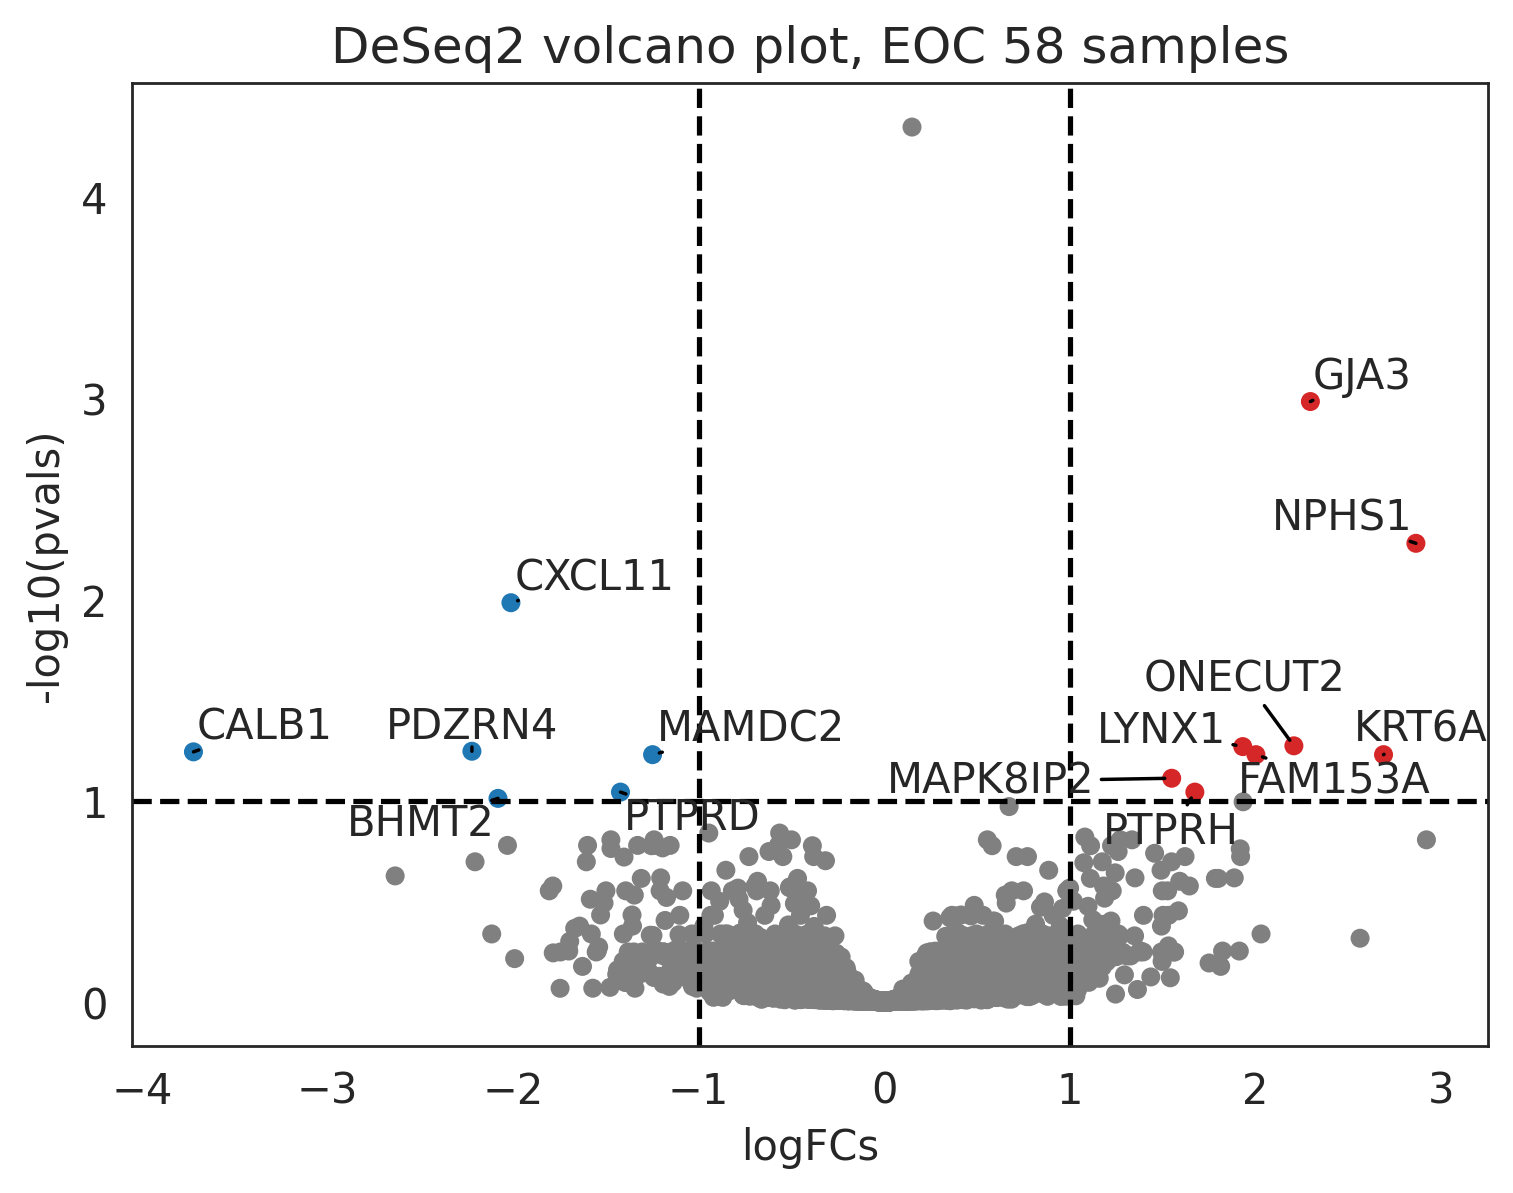

In [126]:
dc.plot_volcano_df(results_df, x='log2FoldChange',
                   y='padj', top=25, dpi=250, lFCs_thr=1., sign_limit=6, sign_thr=0.1,
                  
                  )
plt.title('DeSeq2 volcano plot, EOC 58 samples')

# plt.savefig('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/EOC_Volcano_DeSeq2.pdf',
#             dpi=600,
#            format='pdf', bbox_inches='tight')

plt.show()

In [67]:
mat = results_df[['stat']].T.rename(index={'stat': 'Refractory.vs.Responsive'})
mat

geneName,FO538757.1,SAMD11,NOC2L,KLHL17,PLEKHN1,HES4,ISG15,AGRN,C1orf159,TTLL10,TNFRSF18,SDF4,B3GALT6,FAM132A,UBE2J2,SCNN1D,ACAP3,PUSL1,CPSF3L,CPTP,TAS1R3,DVL1,MXRA8,AURKAIP1,CCNL2,MRPL20,ANKRD65,VWA1,ATAD3C,ATAD3B,ATAD3A,TMEM240,SSU72,FNDC10,MIB2,MMP23B,CDK11B,SLC35E2B,CDK11A,SLC35E2,...,ATP6AP1,GDI1,FAM50A,PLXNA3,LAGE3,UBL4A,SLC10A3,FAM3A,G6PD,IKBKG,GAB3,DKC1,MPP1,F8,F8A1,FUNDC2,CMC4,MTCP1,BRCC3,VBP1,RAB39B,CLIC2,F8A3,TMLHE,SPRY3,VAMP7,IL9R,MT-ND1,MT-ND2,MT-CO1,MT-CO2,MT-ATP8,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
Refractory.vs.Responsive,-0.136531,0.331114,-0.230529,-1.013751,1.442149,1.457586,-3.542646,0.474971,-0.172249,0.985164,1.279252,0.015968,0.582067,0.828624,0.38535,0.765516,0.28863,1.319696,0.074893,0.21702,1.777467,0.544255,1.925305,-0.267746,0.770545,-1.132707,1.871348,0.624382,1.708229,-0.157087,0.014641,0.433764,0.253297,0.779294,-0.139742,2.387635,0.252235,0.738798,0.277793,-0.421672,...,-1.588596,-0.084337,0.003616,1.019113,-0.126015,-1.545905,-1.074442,-1.3122,-1.094129,-1.014306,-1.068194,-1.7162,-1.302967,-0.963175,-1.861934,-0.600415,-1.454482,-1.305656,-2.357302,-1.057821,-1.064556,-0.566836,-0.012488,-0.400364,-0.448415,-2.075538,-1.137841,1.622651,1.77146,0.822183,0.667498,1.616114,1.526698,0.670309,0.73009,0.764609,1.382768,1.861323,-0.203862,1.93405


In [68]:
refr_samples = ann[ann.Status == 'Refractory'].index
resp_samples = ann[ann.Status == 'Responsive'].index

## Transcriptional factor activity

In [69]:
# Retrieve CollecTRI gene regulatory network
collectri.head(3)

,source,target,weight,PMID
0,MYC,TERT,1,10022128;10491298;10606235;10637317;10723141;1...
1,SPI1,BGLAP,1,10022617
2,SMAD3,JUN,1,10022869;12374795


In [70]:
collectri.target.nunique()

6692

In [71]:
collectri.source.nunique()

1186

In [72]:
collectri.target.nunique()

6692

In [73]:
# Infer TF activities with ulm
tf_acts, tf_pvals = dc.run_ulm(mat=mat,
                               net=collectri,
                               verbose=True, min_n=10)
tf_acts

Running ulm on mat with 1 samples and 14709 targets for 493 sources.


,ABL1,AHR,AIRE,AP1,APEX1,AR,ARID4B,ARNT,ARX,ASCL1,ATF1,ATF2,ATF3,ATF4,ATF5,ATF6,BACH1,BARX2,BCL11B,BCL3,BCL6,BHLHA15,BHLHE40,BHLHE41,BMAL1,BRCA1,BRD4,CDX1,CDX2,CEBPA,CEBPB,CEBPD,CEBPE,CEBPG,CEBPZ,CIITA,CLOCK,CREB1,CREB3,CREB5,...,TRPS1,TTF1,TWIST1,TWIST2,USF1,USF2,VDR,VHL,VSX2,WT1,XBP1,YBX1,YBX3,YY1,ZBED1,ZBTB16,ZBTB17,ZBTB33,ZBTB4,ZBTB7A,ZBTB7B,ZEB1,ZEB2,ZFP42,ZFPM1,ZFPM2,ZGLP1,ZIC1,ZKSCAN7,ZNF143,ZNF148,ZNF331,ZNF350,ZNF354C,ZNF362,ZNF382,ZNF384,ZNF699,ZNF804A,ZNF91
Refractory.vs.Responsive,2.359842,0.839412,-0.230342,1.696163,0.975316,2.629781,-2.37696,0.699844,1.37168,0.938358,0.05392,0.91964,1.663722,1.218693,0.603028,0.442572,0.522992,0.46982,-0.070344,0.364046,1.749814,-0.306603,0.684372,-0.383061,0.990484,-1.241887,0.075615,-1.522574,0.034334,-0.165993,-0.527336,-0.191394,-0.489917,0.572281,1.482997,-1.50576,0.949398,1.954133,0.526209,0.27214,...,-1.317773,1.88654,-0.688307,-0.676602,-0.994751,-0.525713,0.283369,-0.342448,-1.536539,1.642042,-0.067649,0.655598,-0.077651,0.245626,0.14044,-0.104273,0.78505,0.279553,-0.204124,-0.135541,-0.233178,-0.681427,-0.199633,-1.699211,-0.731646,-0.252605,-0.519717,1.117282,0.010474,-0.623063,0.221345,0.096341,-1.776827,2.01474,-0.565066,0.337015,-0.017105,-0.873722,-0.351782,0.456201


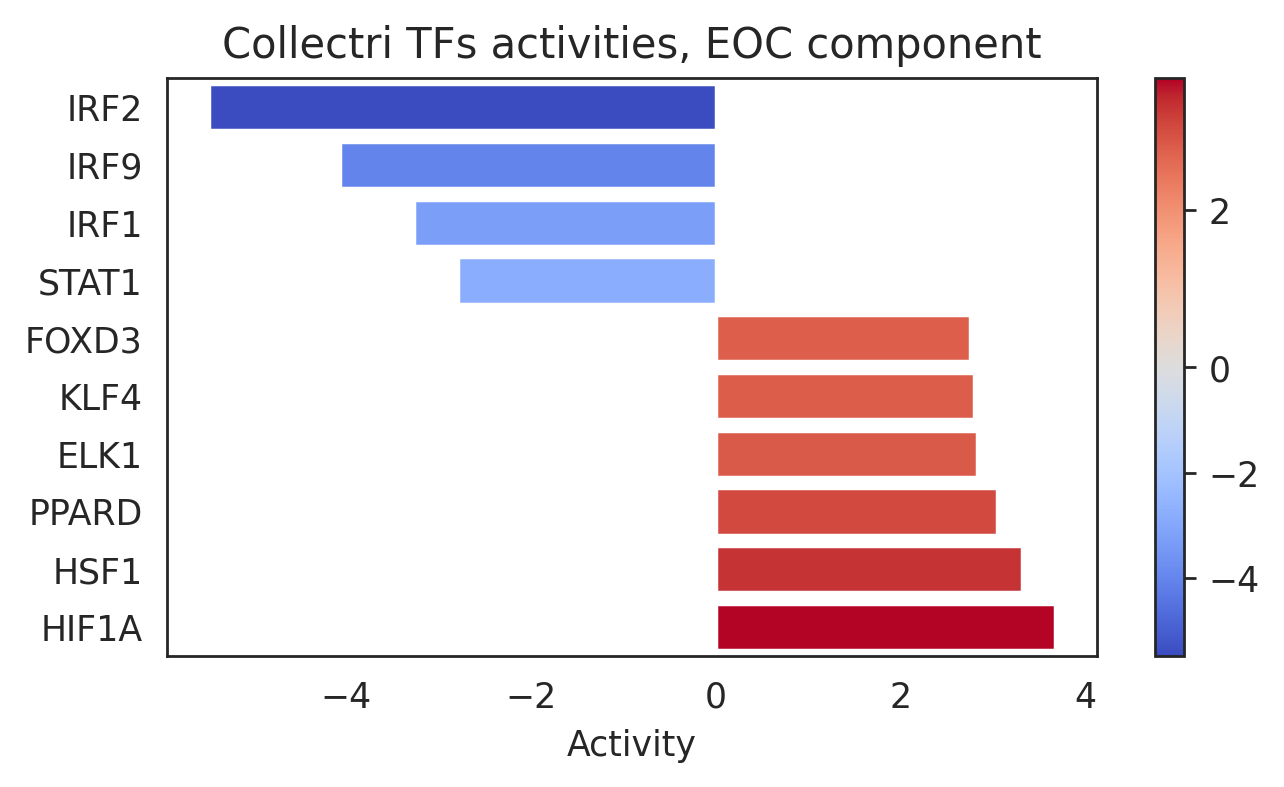

In [74]:
dc.plot_barplot(tf_acts, 'Refractory.vs.Responsive', top=10, vertical=True, figsize=(6,3)
                , dpi=250
               )
plt.title('Collectri TFs activities, EOC component')


plt.show()

In [75]:
pd.concat([tf_acts.T.sort_values('Refractory.vs.Responsive').tail(5), 
           tf_acts.T.sort_values('Refractory.vs.Responsive').head(5)]).sort_values('Refractory.vs.Responsive')

,Refractory.vs.Responsive
IRF2,-5.473204
IRF9,-4.060981
IRF1,-3.255226
STAT1,-2.782837
IRF3,-2.660976
KLF4,2.792932
ELK1,2.831290
PPARD,3.038870
HSF1,3.316698
HIF1A,3.666918


In [139]:
tf_pvals[['HIF1A', 'HSF1', 'PPARD', 'ELK1', 'KLF4', 'IRF3', 'STAT1', 'IRF2', 'IRF9', 'IRF1']]

,HIF1A,HSF1,PPARD,ELK1,KLF4,IRF3,STAT1,IRF2,IRF9,IRF1
Refractory.vs.Responsive,0.000246,0.000913,0.002379,0.004642,0.00523,0.0078,0.005395,4.492055e-08,0.000049,0.001136


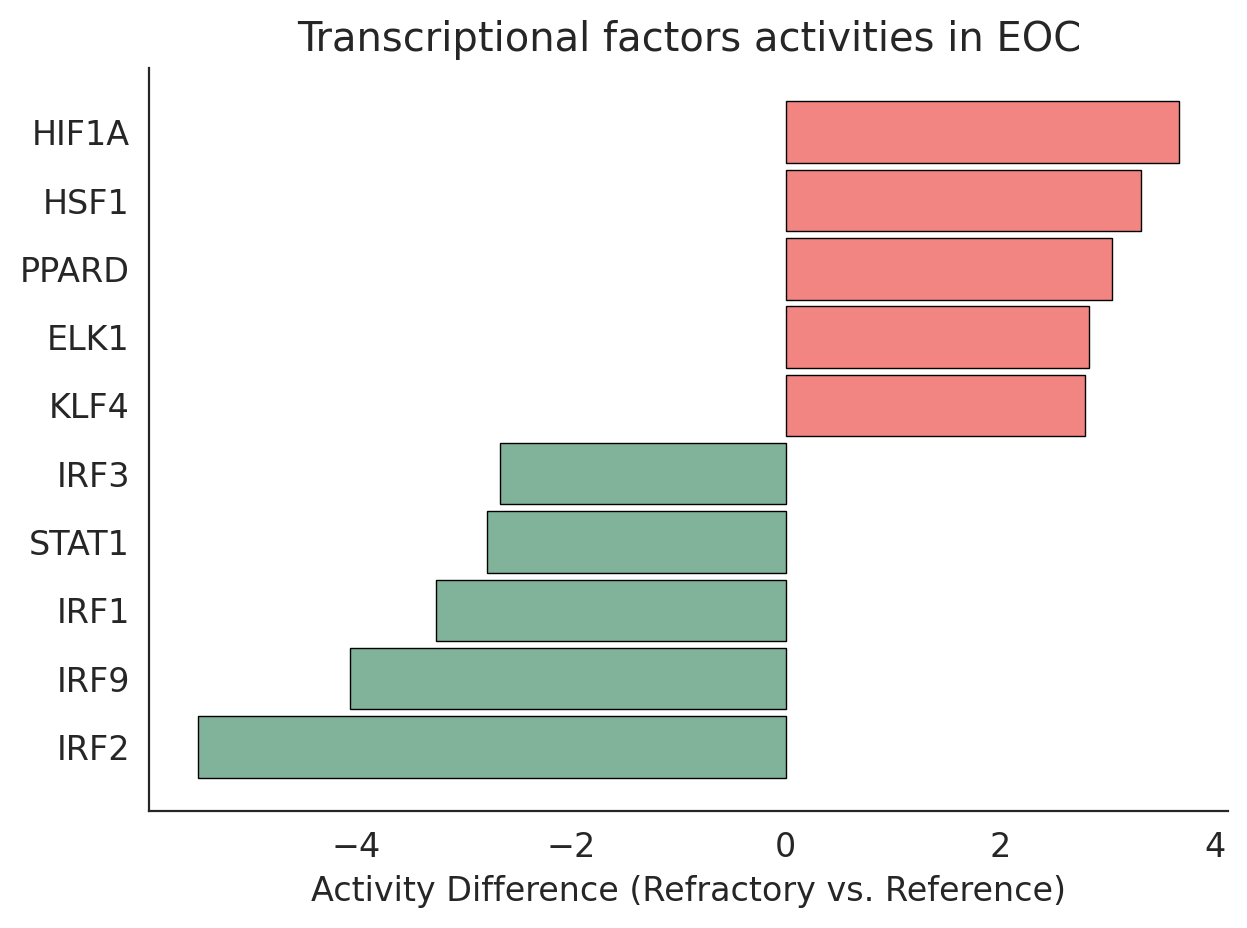

In [127]:
fig, ax = plt.subplots()

data_sorted = pd.concat([tf_acts.T.sort_values('Refractory.vs.Responsive').tail(5), 
                         tf_acts.T.sort_values('Refractory.vs.Responsive').head(5)]).\
                                sort_values('Refractory.vs.Responsive')
data_sorted['TF'] = data_sorted.index

colors = ['#f28482' if x > 0 else '#81b29a' for x in data_sorted['Refractory.vs.Responsive']]

ax.barh(data_sorted['TF'],
        data_sorted['Refractory.vs.Responsive'], 
        color=colors, height=0.9,
        edgecolor='black', linewidth=0.5) 


ax.set_title('Transcriptional factors activities in EOC')
ax.set_xlabel('Activity Difference (Refractory vs. Reference)')


plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})


spines_to_remove = ['top', 'right']
for spine in spines_to_remove:
    ax.spines[spine].set_visible(False)


plt.tight_layout()

# plt.savefig('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/EOC_Collectri.pdf',
#             dpi=600,
#            format='pdf', bbox_inches='tight')

plt.show()

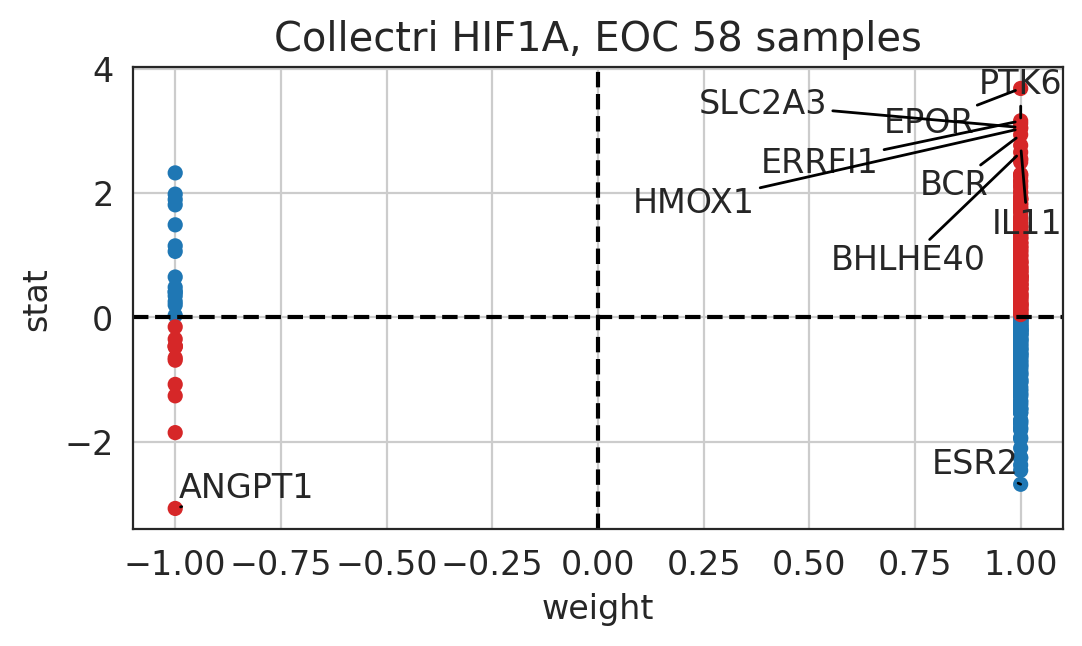

In [223]:
dc.plot_targets(results_df, stat='stat', source_name='HIF1A',
                net=collectri, top=10, figsize=(6,3),
               dpi=200
               )
plt.title('Collectri HIF1A, EOC 58 samples')

# plt.savefig('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/HIF1A_Collectri.pdf',
#             dpi=600,
#            format='pdf', bbox_inches='tight')

plt.show()

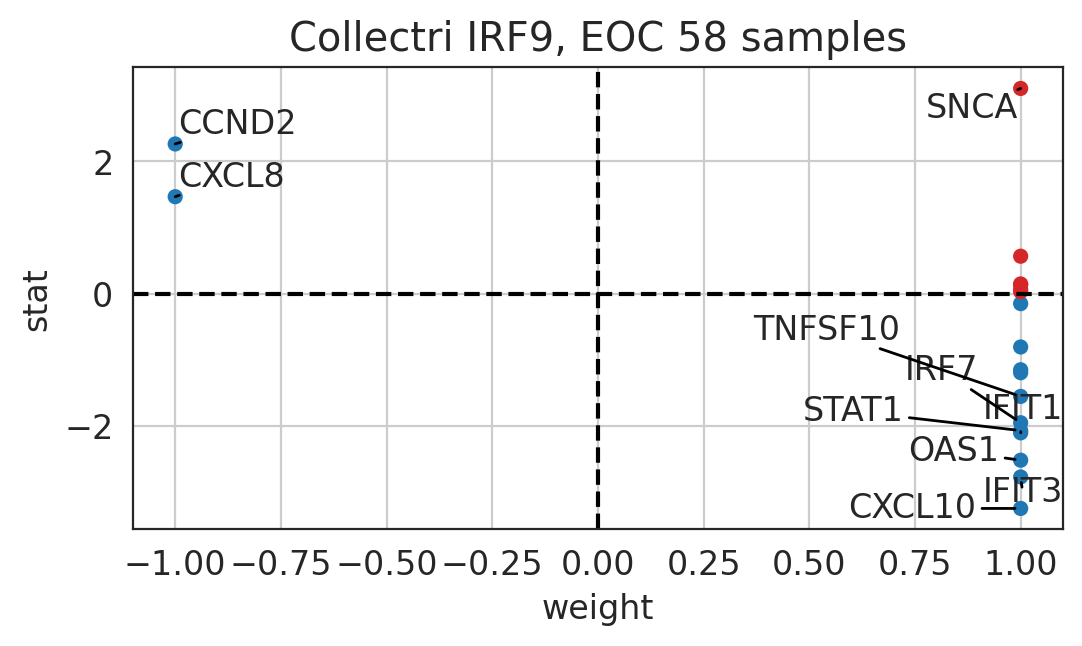

In [224]:
dc.plot_targets(results_df, stat='stat', source_name='IRF9',
                net=collectri, top=10, figsize=(6,3),
               dpi=200
               )
plt.title('Collectri IRF9, EOC 58 samples')

# plt.savefig('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/IRF9_Collectri.pdf',
#             dpi=600,
#            format='pdf', bbox_inches='tight')

plt.show()

## Pathway activity inference

In [80]:
# Retrieve PROGENy model weights
progeny.head(3)

,source,target,weight,p_value
0,Androgen,TMPRSS2,11.490631,0.000000e+00
1,Androgen,NKX3-1,10.622551,2.242078e-44
2,Androgen,MBOAT2,10.472733,4.624285e-44


In [81]:
# Infer pathway activities with mlm
pathway_acts, pathway_pvals = dc.run_mlm(mat=mat, net=progeny, verbose=True,)
pathway_acts

Running mlm on mat with 1 samples and 14709 targets for 14 sources.


,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
Refractory.vs.Responsive,1.090714,0.244663,1.877627,4.895251,-18.668917,1.701264,0.321853,0.55471,-3.73848,-0.082021,1.173391,0.502914,-0.927463,1.2193


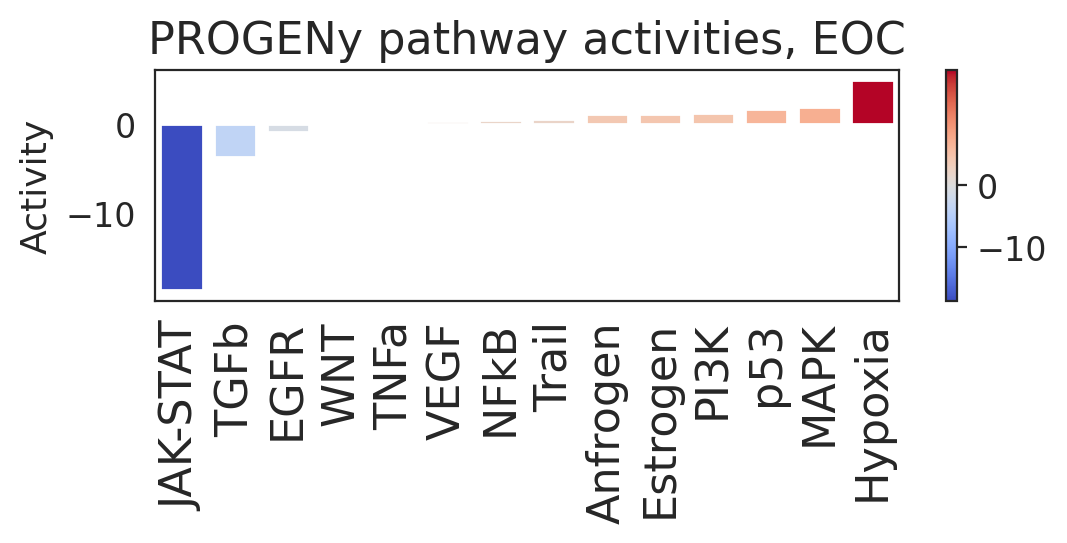

In [82]:
# plt.style.use('ggplot')
fig = dc.plot_barplot(pathway_acts, 'Refractory.vs.Responsive',
                top=25, vertical=False, dpi=200, figsize=(6,1.5),)
plt.title('PROGENy pathway activities, EOC', fontsize=16)
plt.xticks(ticks=range(14), labels=['JAK-STAT', 'TGFb', 'EGFR', 'WNT', 'TNFa',
                 'VEGF', 'NFkB', 'Trail', 'Anfrogen', 'Estrogen',
                 'PI3K', 'p53', 'MAPK', 'Hypoxia'], fontsize=16)
plt.ylabel('Activity', fontsize=13)

plt.show()

In [132]:
pathway_pvals

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
Refractory.vs.Responsive,0.275417,0.806721,0.060452,9.922263e-07,0.0,0.088915,0.747569,0.579102,0.000186,0.934631,0.240658,0.615032,0.353701,0.22275


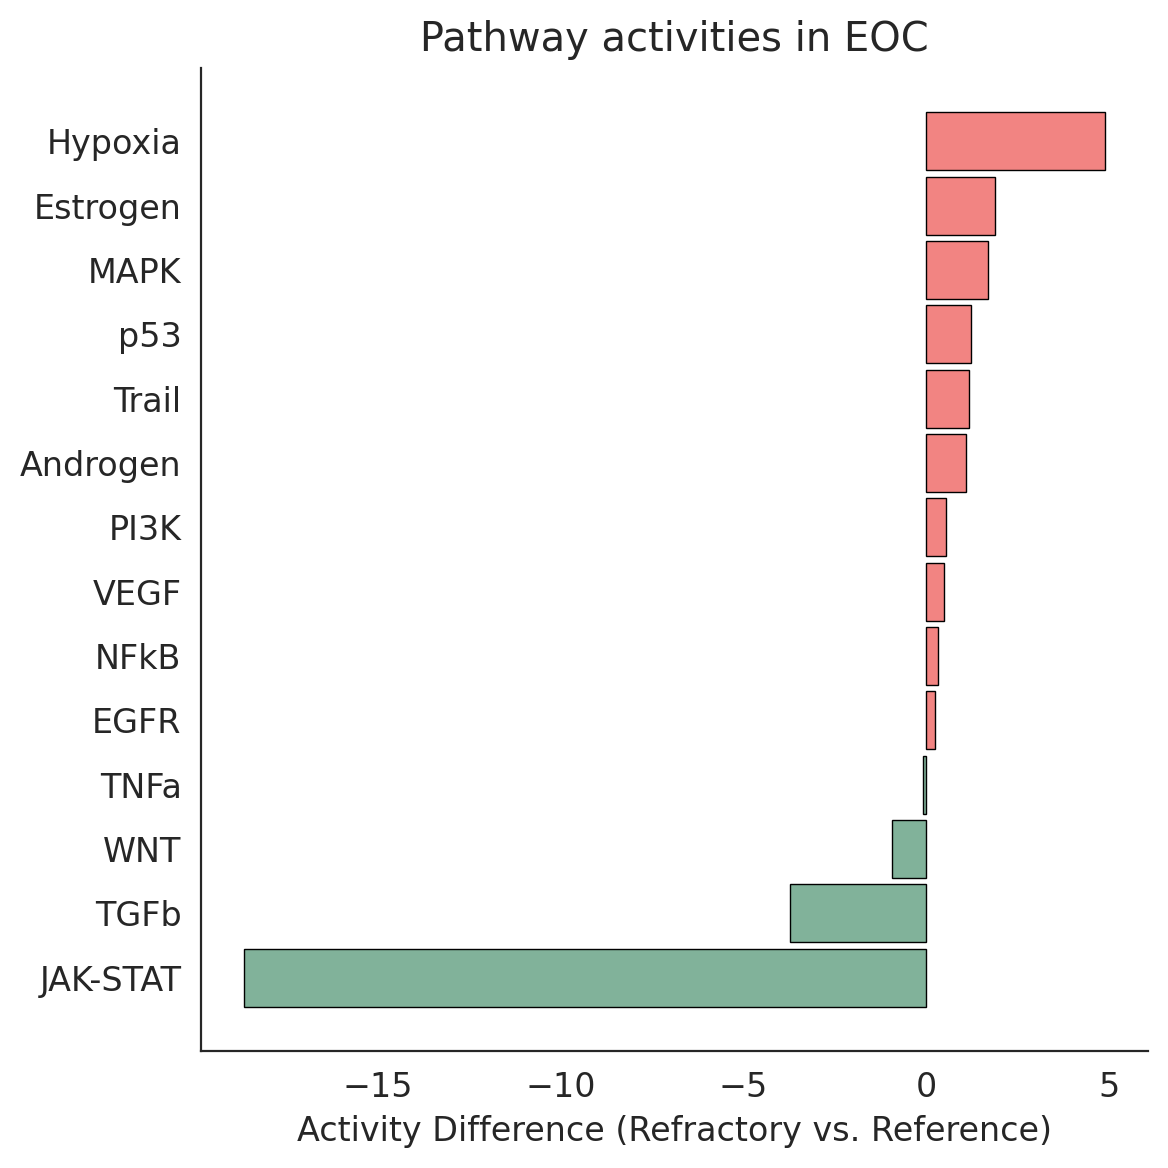

In [130]:
fig, ax = plt.subplots(figsize=(6, 6))

data_sorted = pathway_acts.T.sort_values('Refractory.vs.Responsive')
data_sorted['Pathway'] = data_sorted.index

colors = ['#f28482' if x > 0 else '#81b29a' for x in data_sorted['Refractory.vs.Responsive']]

ax.barh(data_sorted['Pathway'],
        data_sorted['Refractory.vs.Responsive'], 
        color=colors, height=0.9,
        edgecolor='black', linewidth=0.5) 


ax.set_title('Pathway activities in EOC')
ax.set_xlabel('Activity Difference (Refractory vs. Reference)')

plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

spines_to_remove = ['top', 'right']
for spine in spines_to_remove:
    ax.spines[spine].set_visible(False)

plt.tight_layout()

# plt.savefig('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/EOC_Progeny.pdf',
#             dpi=600,
#            format='pdf', bbox_inches='tight')

plt.show()

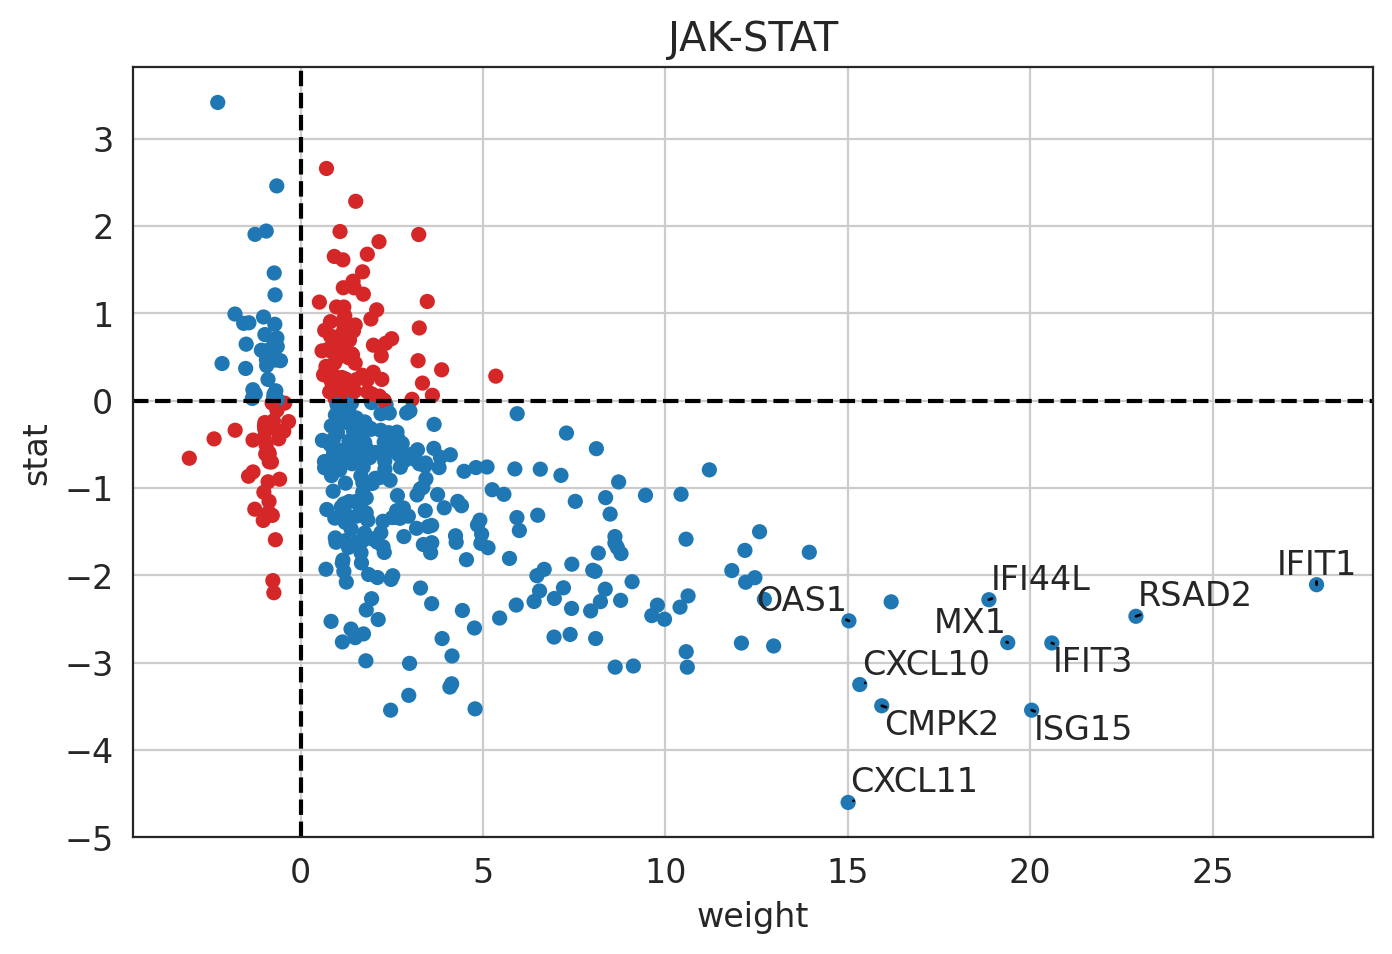

In [131]:
f1 = dc.plot_targets(results_df, stat='stat',
                source_name='JAK-STAT', net=progeny,
                top=10, dpi=200, figsize=(8,5), return_fig=True)

# plt.savefig('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/EOC_Progeny_JAKSTATtargets.pdf',
#             dpi=600,
#            format='pdf', bbox_inches='tight')

plt.show()

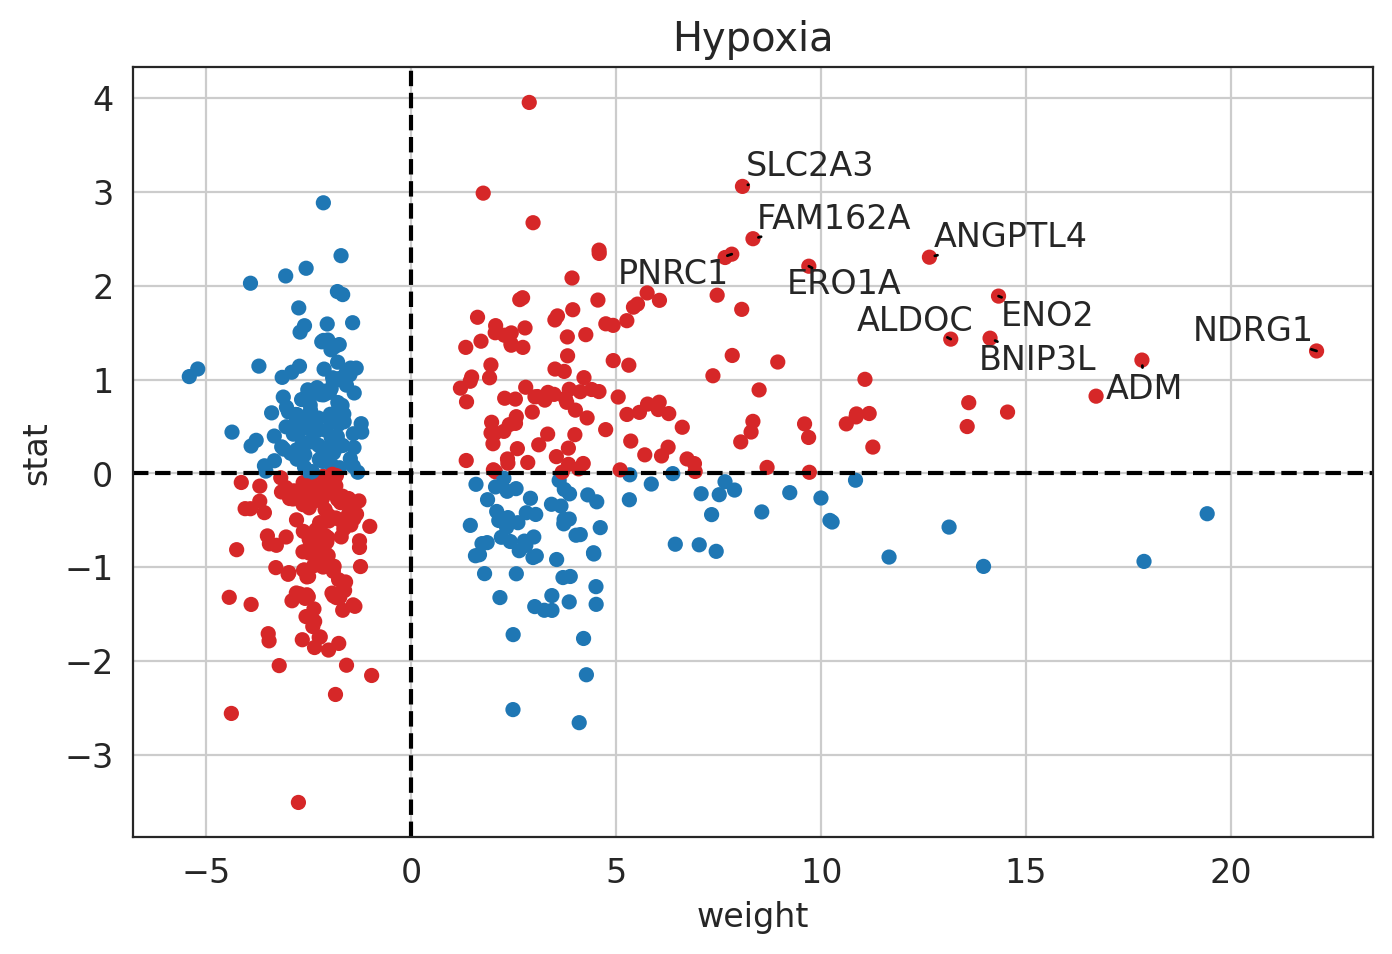

In [208]:
f1 = dc.plot_targets(results_df, stat='stat',
                source_name='Hypoxia', net=progeny,
                top=10, dpi=200, figsize=(8,5), return_fig=True)

# plt.savefig('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v3_CRM/plots/EOC_Progeny_JAKSTATtargets.pdf',
#             dpi=600,
#            format='pdf', bbox_inches='tight')

plt.show()

## Per-sample pathway scores

In [85]:
adata.raw = adata

In [86]:
dc.run_mlm(
    mat=adata,
    net=progeny,
    source='source',
    target='target',
    weight='weight',
    verbose=True
)

Running mlm on mat with 58 samples and 14709 targets for 14 sources.


In [87]:
adata.obsm['progeny_mlm_estimate'] = adata.obsm['mlm_estimate'].copy()
adata.obsm['progeny_mlm_pvals'] = adata.obsm['mlm_pvals'].copy()
adata

AnnData object with n_obs × n_vars = 58 × 14709
    obs: 'condition', 'patient', 'tissue', 'HRD', 'sample_id'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors', 'replaceable', 'mlm_estimate', 'mlm_pvals', 'progeny_mlm_estimate', 'progeny_mlm_pvals'
    varm: 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', '_normed_means', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced'
    layers: 'normed_counts', '_mu_hat', '_mu_LFC', '_hat_diagonals', 'cooks', 'replace_cooks'

In [88]:
acts = dc.get_acts(adata, obsm_key='mlm_estimate')
acts

AnnData object with n_obs × n_vars = 58 × 14
    obs: 'condition', 'patient', 'tissue', 'HRD', 'sample_id'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors', 'replaceable', 'mlm_estimate', 'mlm_pvals', 'progeny_mlm_estimate', 'progeny_mlm_pvals'

In [89]:
ann['Hypoxia'] = acts.obsm['mlm_estimate']['Hypoxia']
ann['JAK-STAT'] = acts.obsm['mlm_estimate']['JAK-STAT']

# Functional enrichment of biological terms

In [90]:
import gseapy as gp

In [91]:
EOC_tmm_study = EOC_tmm[ann['sample'].values]
EOC_tmm_study.columns = ann[ann['sample'].isin(EOC_tmm_study.columns)].index
EOC_tmm_study.head(5)

plot_code,EOC1023_Ome,EOC868_Per,EOC551_Ova,EOC60_Per,EOC1133_Per,EOC26_Ome,EOC218_Ome,EOC1032_Per,EOC167_Ome,EOC183_Ome,EOC376_Ome,EOC1129_Ome,EOC372_Per,EOC423_Ome,EOC87_Ome,EOC295_Per,EOC587_Adn,EOC649_Ome,EOC933_Ome,EOC691_Per,EOC49_Ome,EOC3_Ome,EOC136_Per,EOC153_Ome,EOC1127_Ome,EOC115_Per,EOC192_Ome,EOC197_Per,EOC991_Ome,EOC658_Per,EOC227_Ome,EOC473_Ome,EOC1107_Ome,EOC1075_Tub,EOC373_Adn,EOC198_Per,EOC175_Ome,EOC612_Ome,EOC449_Per,EOC1017_Ome,EOC888_Ome,EOC294_Per,EOC257_Per,EOC984_Ome,EOC359_Ome,EOC523_Ome,EOC138_Per,EOC1038_Tub,EOC268_Per,EOC864_Oth,EOC351_Per,EOC323_Ova,EOC1085_Per,EOC958_Per,EOC150_Tub,EOC824_Per,EOC768_Per,EOC221_Per
geneName,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
OR4F5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.051444,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
FO538757.2,0.000000,0.000000,0.000000,0.000000,0.000000,0.034455,9.725842e-07,0.000000,0.000000,0.000000,0.062935,0.203117,0.180691,0.000000,0.000000,0.000000,0.000000,0.000000,0.000001,1.509039,0.001124,0.001072,0.000000,0.001276,0.017395,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.006995,0.569821,0.000000,0.000000,0.000139,0.614678,0.000000,0.000192,0.000000,0.000000,5.501710e-07,0.208925,0.000000,0.000000,0.000000,0.403311,0.000000,0.000000,0.000000,0.000000,2.756804,0.000000,0.000000,0.000000,0.000000,0.000000,0.000054
FO538757.1,400.697904,513.147493,428.065395,362.914340,520.941531,706.963497,2.970956e+02,438.570993,525.802600,262.134586,575.879072,451.403423,376.195720,209.702144,156.691768,432.416263,139.621770,753.909384,1115.298106,756.867243,81.668693,580.227583,214.399707,807.493320,684.827767,379.346553,265.8357,368.690848,443.992650,256.669388,415.975017,345.022719,778.343535,126.576406,267.014426,154.173751,157.623922,190.347971,258.159674,172.797187,150.074984,3.882235e+02,292.487744,146.566762,455.494644,235.952815,307.859256,437.159223,460.766998,453.042774,341.117289,308.764346,324.247442,474.350544,151.999543,95.731726,92.838360,136.021776
OR4F29,0.000000,0.081478,0.549185,0.565796,0.000000,0.000000,0.000000e+00,0.598811,0.285428,0.356471,0.001946,0.043993,0.236853,0.000000,0.714367,0.000000,0.038299,1.136910,3.088332,0.000000,0.703179,0.218001,0.463354,0.816320,0.000000,1.437918,0.0000,0.000066,0.392574,0.131869,0.025913,0.049037,0.114765,0.127692,0.255391,0.333578,0.749405,0.290371,1.678348,0.000000,0.411113,1.269627e-03,0.088548,0.039791,0.000000,0.312014,0.000000,0.000000,0.765248,0.122943,1.185126,0.359541,0.000000,1.134267,0.251374,0.517961,0.133297,0.313337
OR4F16,0.000000,0.081478,0.549185,0.565796,0.000000,0.000000,0.000000e+00,0.598811,0.285428,0.356471,0.001946,0.043993,0.236853,0.000000,0.714367,0.000000,0.038299,1.136910,3.088332,0.000000,0.703179,0.218001,0.463354,0.816320,0.000000,1.437918,0.0000,0.000066,0.392574,0.131869,0.025913,0.049037,0.114765,0.127692,0.255391,0.333578,0.749405,0.290371,1.678348,0.000000,0.411113,1.269627e-03,0.088548,0.039791,0.000000,0.312014,0.000000,0.000000,0.765248,0.122943,1.185126,0.359541,0.000000,1.134267,0.251374,0.517961,0.133297,0.313337


In [92]:
# run gsea
# enrichr libraries are supported by gsea module. Just provide the name
gs_res = gp.gsea(data=EOC_tmm_study[ann.index], # or data='./P53_resampling_data.txt'
                 gene_sets='MSigDB_Hallmark_2020', # or enrichr library names
                 # gene_sets='WikiPathways_2019_Human',
                 cls=ann.Status, # cls=class_vector
                 # set permutation_type to phenotype if samples >=15
                 permutation_type='phenotype',
                 permutation_num=1000, # reduce number to speed up test
                 outdir=None,  # do not write output to disk
                 method='t_test',
                 threads=1, seed= 7, max_size=500)

/mnt/csc-gc8/work/afenteva/virtualenvs/jupyter/lib/python3.8/site-packages/gseapy/gsea.py:120: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[df_std.abs().sum(axis=1) > 0]


In [93]:
gs_res.res2d.sort_values('NES')[:10]

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,gsea,Interferon Gamma Response,-0.587282,-1.872619,0.029297,0.130933,0.048241,128/198,29.25%,LAP3;ISG15;IFI35;CXCL11;DDX58;CD38;PARP12;GBP4...
1,gsea,Interferon Alpha Response,-0.664506,-1.827519,0.051485,0.096477,0.070352,63/95,15.43%,LAP3;ISG15;IFI35;CXCL11;PARP12;GBP4;CXCL10;EPS...
2,gsea,TGF-beta Signaling,-0.473208,-1.489841,0.065259,0.888393,0.478392,26/54,29.11%,ID1;TGIF1;CDK9;PPM1A;FNTA;XIAP;SKIL;NOG;SMAD1;...
3,gsea,Fatty Acid Metabolism,-0.403195,-1.445124,0.073665,0.900596,0.529648,85/156,41.60%,BMPR1B;UBE2L6;GRHPR;ALAD;PSME1;IDH1;ALDH9A1;HS...
4,gsea,Xenobiotic Metabolism,-0.348138,-1.335606,0.087031,1.0,0.658291,100/195,42.90%,FMO3;LPIN2;ACOX3;GCH1;CROT;CYB5A;IDH1;TYR;ALDH...
5,gsea,UV Response Up,-0.346392,-1.279589,0.149912,1.0,0.710553,62/155,32.41%,PTPRD;TAP1;GRPEL1;CNP;PRPF3;EIF5;PARP2;GCH1;PP...
6,gsea,Bile Acid Metabolism,-0.326286,-1.269932,0.128039,1.0,0.719598,66/111,49.69%,CROT;IDH1;PEX16;HSD17B6;SLC27A2;ALDH9A1;SLC27A...
7,gsea,Pperoxisome,-0.349084,-1.255531,0.19469,1.0,0.731658,59/104,45.54%,ESR2;IDH1;SLC27A2;ALDH9A1;ISOC1;ACSL4;PEX11B;C...
8,gsea,heme Metabolism,-0.338477,-1.252654,0.197417,1.0,0.732663,89/191,39.40%,BPGM;LPIN2;ACP5;DAAM1;ALAD;NARF;XK;MOCOS;UBAC1...
9,gsea,Myc Targets V1,-0.408035,-1.250905,0.239923,1.0,0.733668,139/196,48.83%,CLNS1A;PSMD1;PSMD3;VDAC3;DHX15;CCT3;HSPD1;ERH;...


In [95]:
terms = gs_res.res2d['Term']

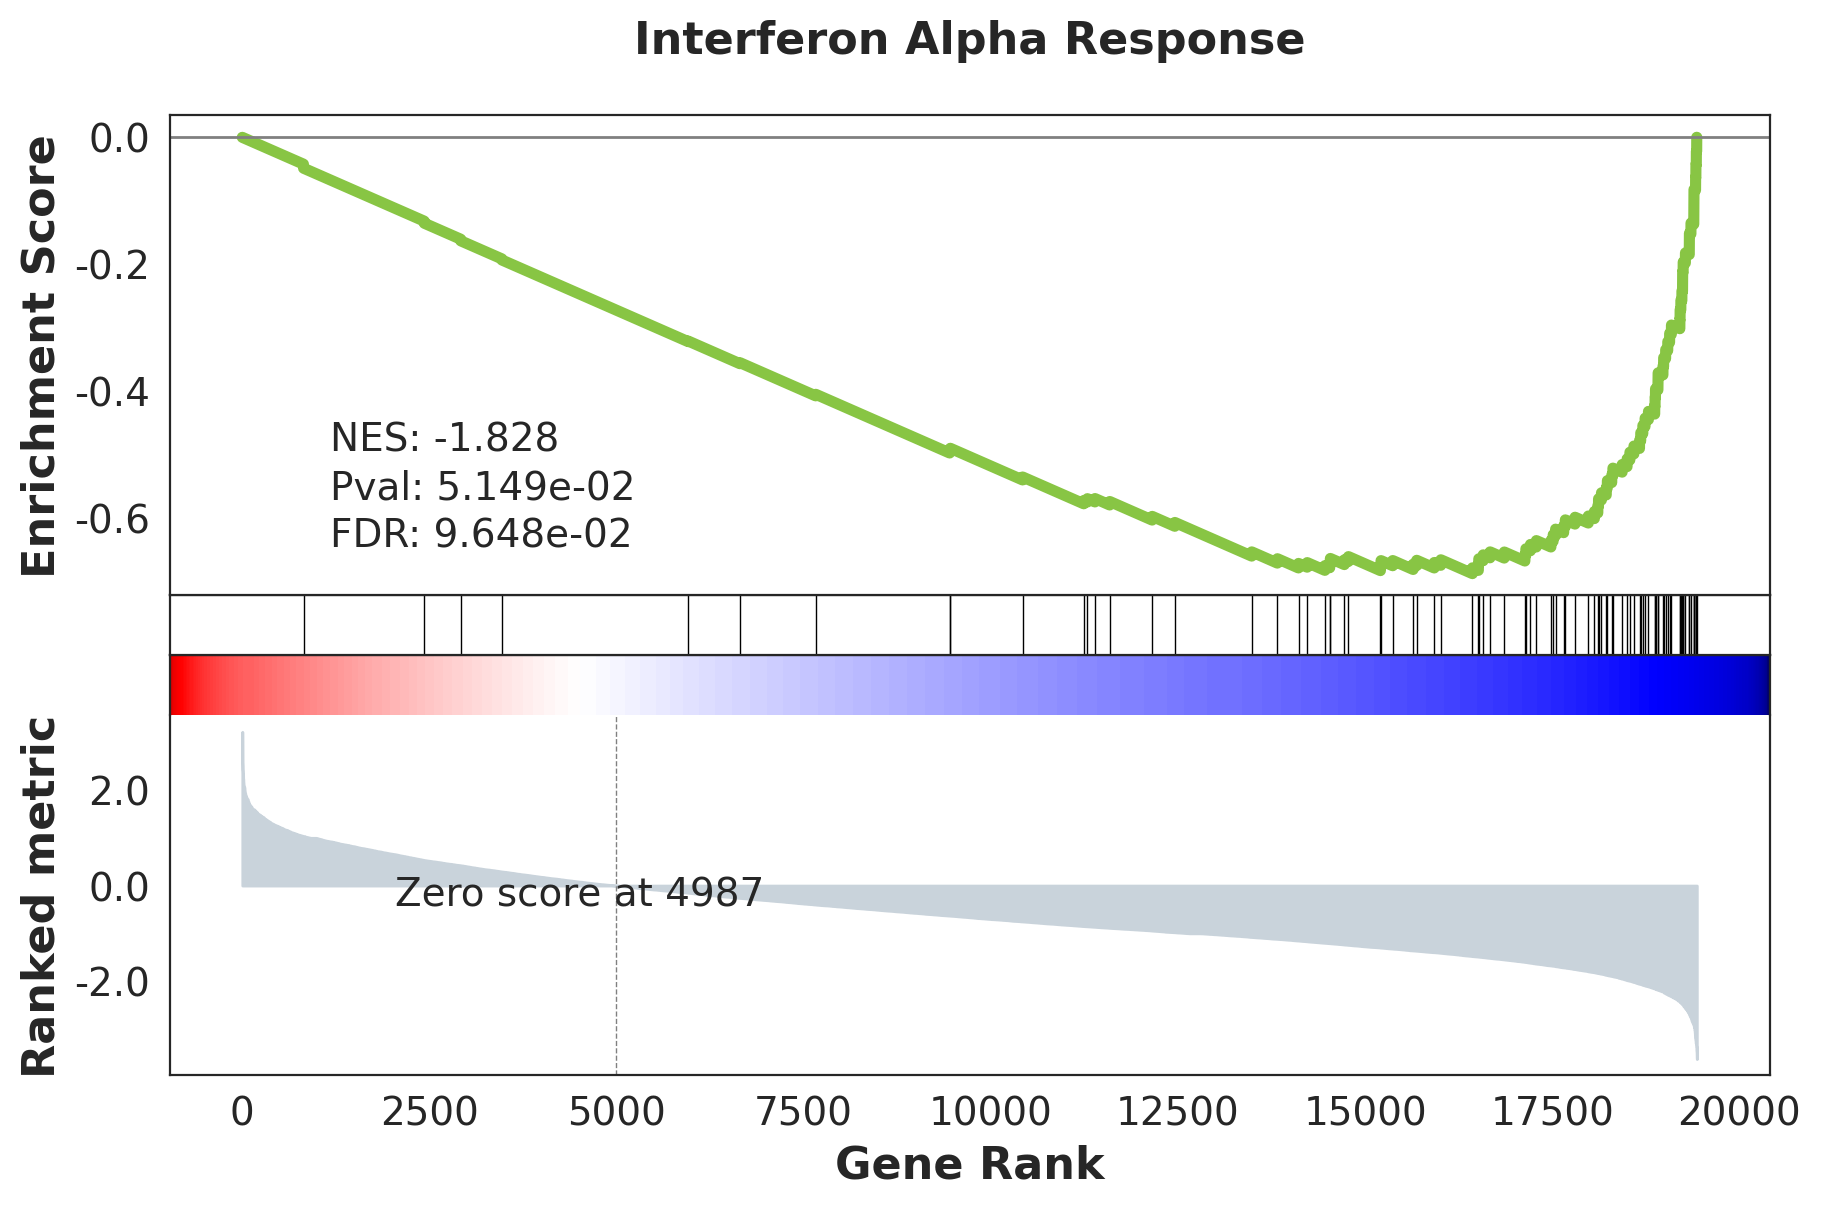

In [96]:
from gseapy import gseaplot
gseaplot(rank_metric=gs_res.ranking,
         term=terms[1],
         **gs_res.results[terms[1]], figsize=(10,6),)
plt.show()

# Hypoxia x JAK-STAT in EOC

In [97]:
hyp_jakstat = pd.read_csv('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER_v2/copyp.tsv',
                   sep='\t', index_col=0)

In [98]:
status_palette = {'Refractory': '#f28482',
                  'Responsive': '#81b29a',
                  'Intermediate': '#70A5CE'}

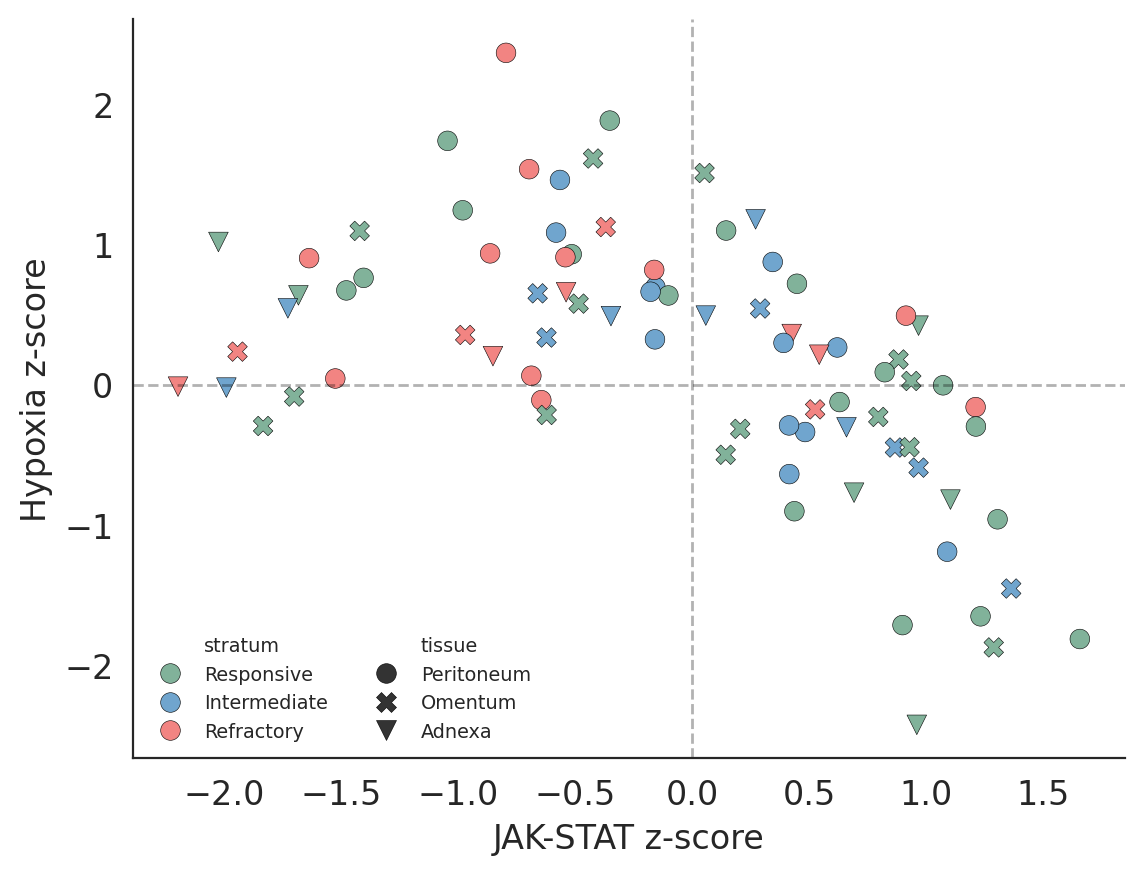

In [99]:
scatter_plot = sns.scatterplot(data=hyp_jakstat,
                x='JAK-STAT',
                y='Hypoxia',
                style='tissue',
                markers=['o','X', 'v'],
                hue='stratum',
                palette=status_palette, alpha=1,
                edgecolor='black', linewidth=0.2,
                legend=True, s=50
               )

plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.3)
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.3)
legend = plt.legend(title='', loc='lower left',
                    frameon=True, framealpha=0, fontsize='xx-small', ncol=2)
plt.xlabel('JAK-STAT z-score')
plt.ylabel('Hypoxia z-score')

spines_to_remove = ['top', 'right']
for spine in spines_to_remove:
    scatter_plot.spines[spine].set_visible(False)

plt.show()

# CycIF

In [101]:
cycif = pd.read_csv('/mnt/storageBig8/work/afenteda/ChemoRef/PAPER/cycif_four_patients.tsv',
            sep='\t', index_col=0)

/tmp/ipykernel_245587/3286142003.py:60: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['EOC3', 'EOC87', 'EOC933', 'EOC940'],


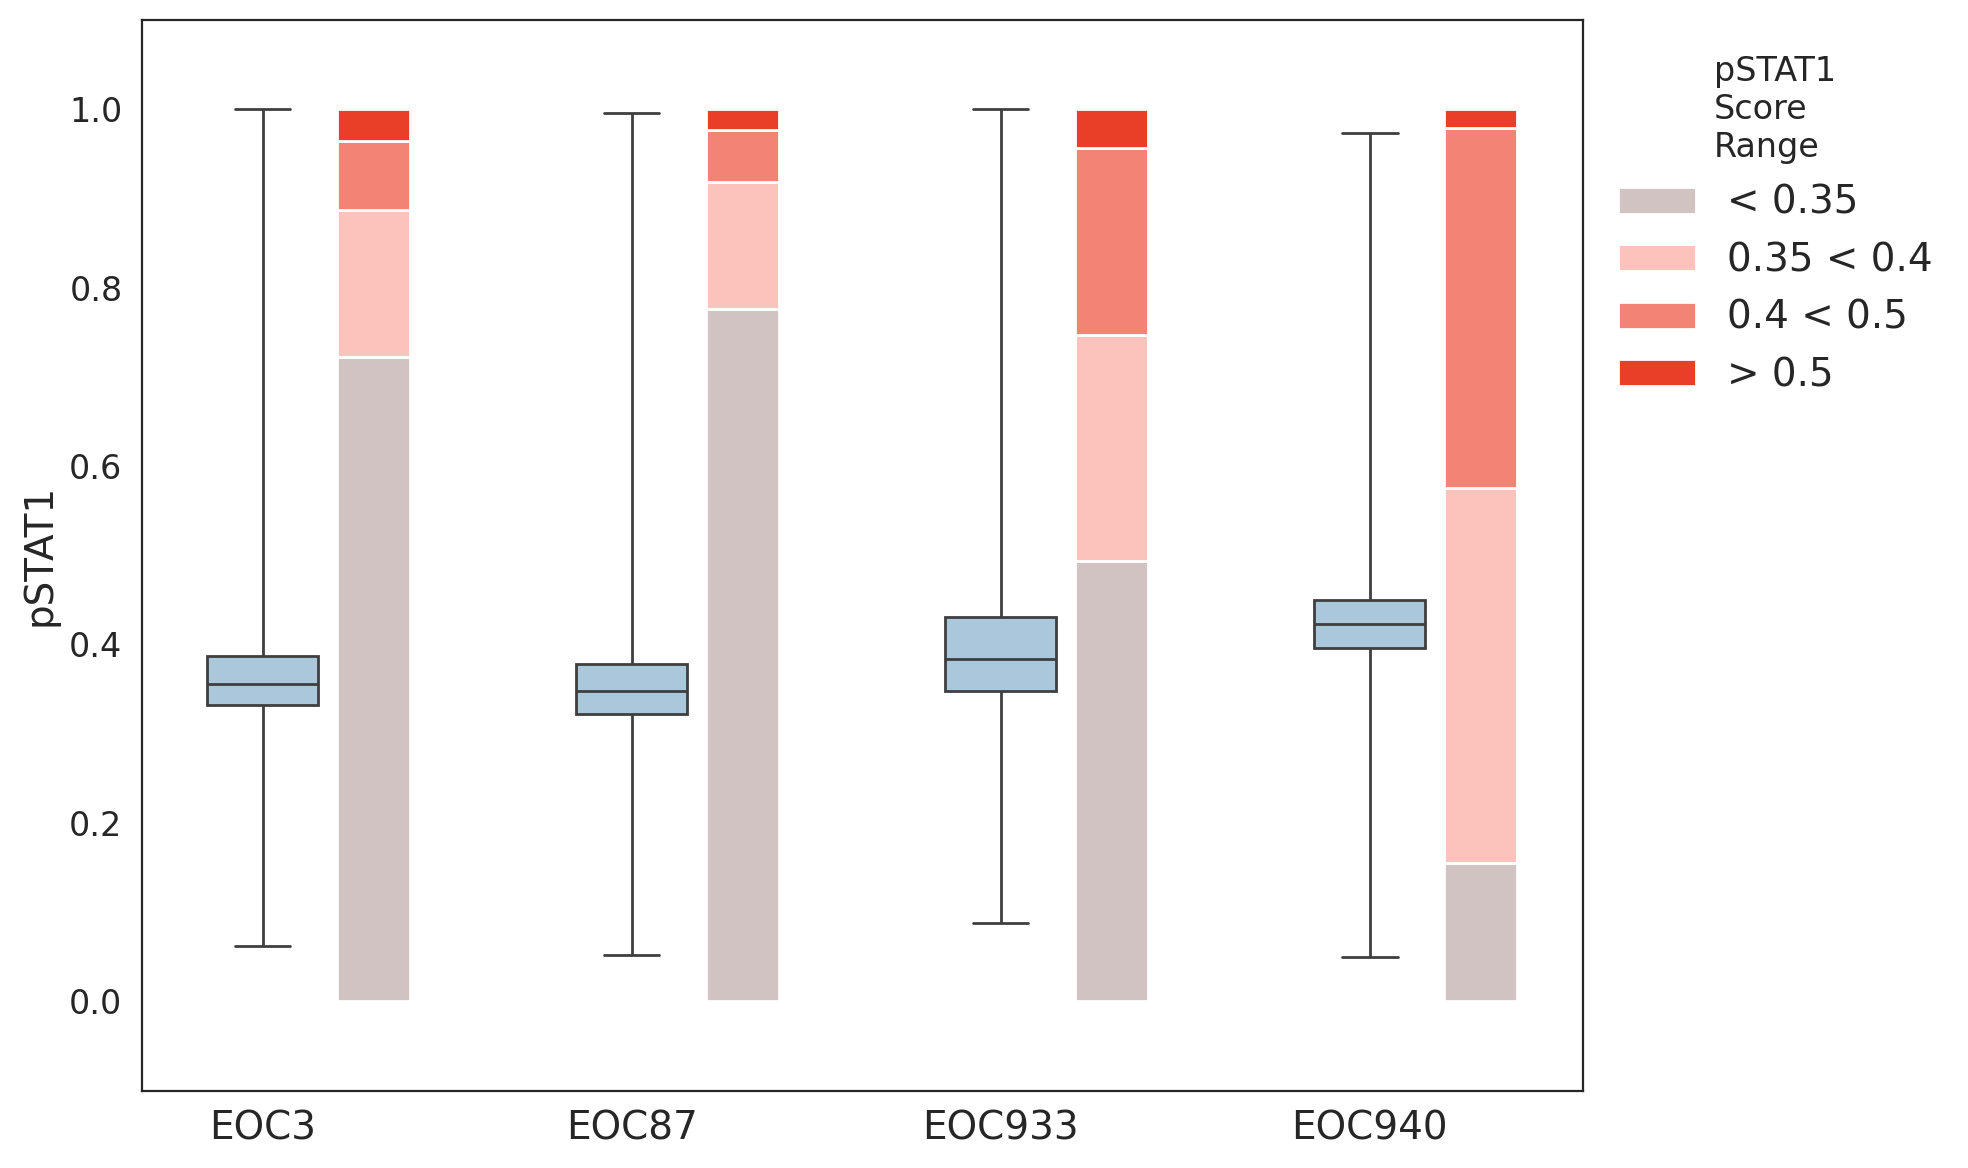

In [102]:
sns.set_style("white")

df = cycif[cycif.GlobalCellType2 == 'Tumor'].copy()

df['sample'] = pd.Categorical(df['patient'],
                              categories=['EOC3', 'EOC87', 'EOC933', 'EOC940'],
                              ordered=True)
df = df.sort_values(by='sample')

# Scale the JAK-STAT scores to be between 0 and 1
df['pSTAT1_scaled'] = (df['pSTAT1'] - df['pSTAT1'].min()) / (df['pSTAT1'].max() - df['pSTAT1'].min())

# Define JAK-STAT score ranges
df['pSTAT1_range'] = pd.cut(df['pSTAT1_scaled'],
                              bins=[-np.inf, 0.35, 0.4, 0.5, np.inf],
                              labels=['< 0.35', '0.35 < 0.4', '0.4 < 0.5', '> 0.5'])

bar_colors = {
    '< 0.35': '#D0C3C1',
    '0.35 < 0.4': '#FBC3BC',
    '0.4 < 0.5': '#F38375',
    '> 0.5': '#E93F29'
}

proportions = df.pivot_table(index='patient',
                             columns='pSTAT1_range',
                             aggfunc='size',
                             fill_value=0,
                             sort=False)
proportions = proportions.div(proportions.sum(axis=1), axis=0) 

f, ax = plt.subplots(figsize=(10, 6)) 

ax = sns.boxplot(x='patient', y='pSTAT1', data=df,
               ax=ax, order=['EOC3', 'EOC87', 'EOC933', 'EOC940'],
               width=0.3, #palette=patient_color,
            saturation=0.8, fliersize=2, linewidth=1, whis=25)
for patch in ax.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.4))


proportions = proportions.loc[['EOC3', 'EOC87', 'EOC933', 'EOC940']]

bottom = np.zeros(len(proportions))
bar_positions = np.arange(len(proportions)) + .3 
bar_width = 0.2

for category in proportions.columns:
    ax.bar(bar_positions, proportions[category],
           bottom=bottom, label=category, width=bar_width,
           color=bar_colors[category],)
    bottom += proportions[category].values

ax.set_xlabel('')
ax.set_ylabel('pSTAT1', fontsize=14)
ax.legend(title='pSTAT1\nScore\nRange', fontsize=14, title_fontsize=12,
          frameon=False, loc='upper left', alignment='center', bbox_to_anchor=(1, 0.5, 0.5, 0.5))
ax.set_ylim(bottom=-0.1,top=1.1)
ax.set_xticklabels(['EOC3', 'EOC87', 'EOC933', 'EOC940'],
                   rotation=0, fontsize=14)

plt.tight_layout()

plt.show()

In [103]:
cycif['GlobalCellType2'].value_counts()

Tumor     745802
Stroma    410511
Immune    267642
Name: GlobalCellType2, dtype: int64

In [109]:
import statsmodels.api as sm

# GEE for tumor cells
model_gee_tumor = sm.GEE.from_formula("pSTAT1 ~ status", groups="patient",
                                      data=cycif[cycif.GlobalCellType2 == 'Tumor'])
result_gee_tumor = model_gee_tumor.fit()
print(result_gee_tumor.summary())

# GEE for stromal cells
model_gee_stroma = sm.GEE.from_formula("pSTAT1 ~ status", groups="patient",
                                       data=cycif[cycif.GlobalCellType2 == 'Stroma'])
result_gee_stroma = model_gee_stroma.fit()
print(result_gee_stroma.summary())

# GEE for immune cells
model_gee_immune = sm.GEE.from_formula("pSTAT1 ~ status", groups="patient",
                                       data=cycif[cycif.GlobalCellType2 == 'Immune'])
result_gee_immune = model_gee_immune.fit()
print(result_gee_immune.summary())

                               GEE Regression Results                              
Dep. Variable:                      pSTAT1   No. Observations:               745802
Model:                                 GEE   No. clusters:                        4
Method:                        Generalized   Min. cluster size:               20919
                      Estimating Equations   Max. cluster size:              380605
Family:                           Gaussian   Mean cluster size:            186450.5
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Tue, 21 Jan 2025   Scale:                           0.005
Covariance type:                    robust   Time:                         12:37:22
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.3655      0.005     76.767      0.000  

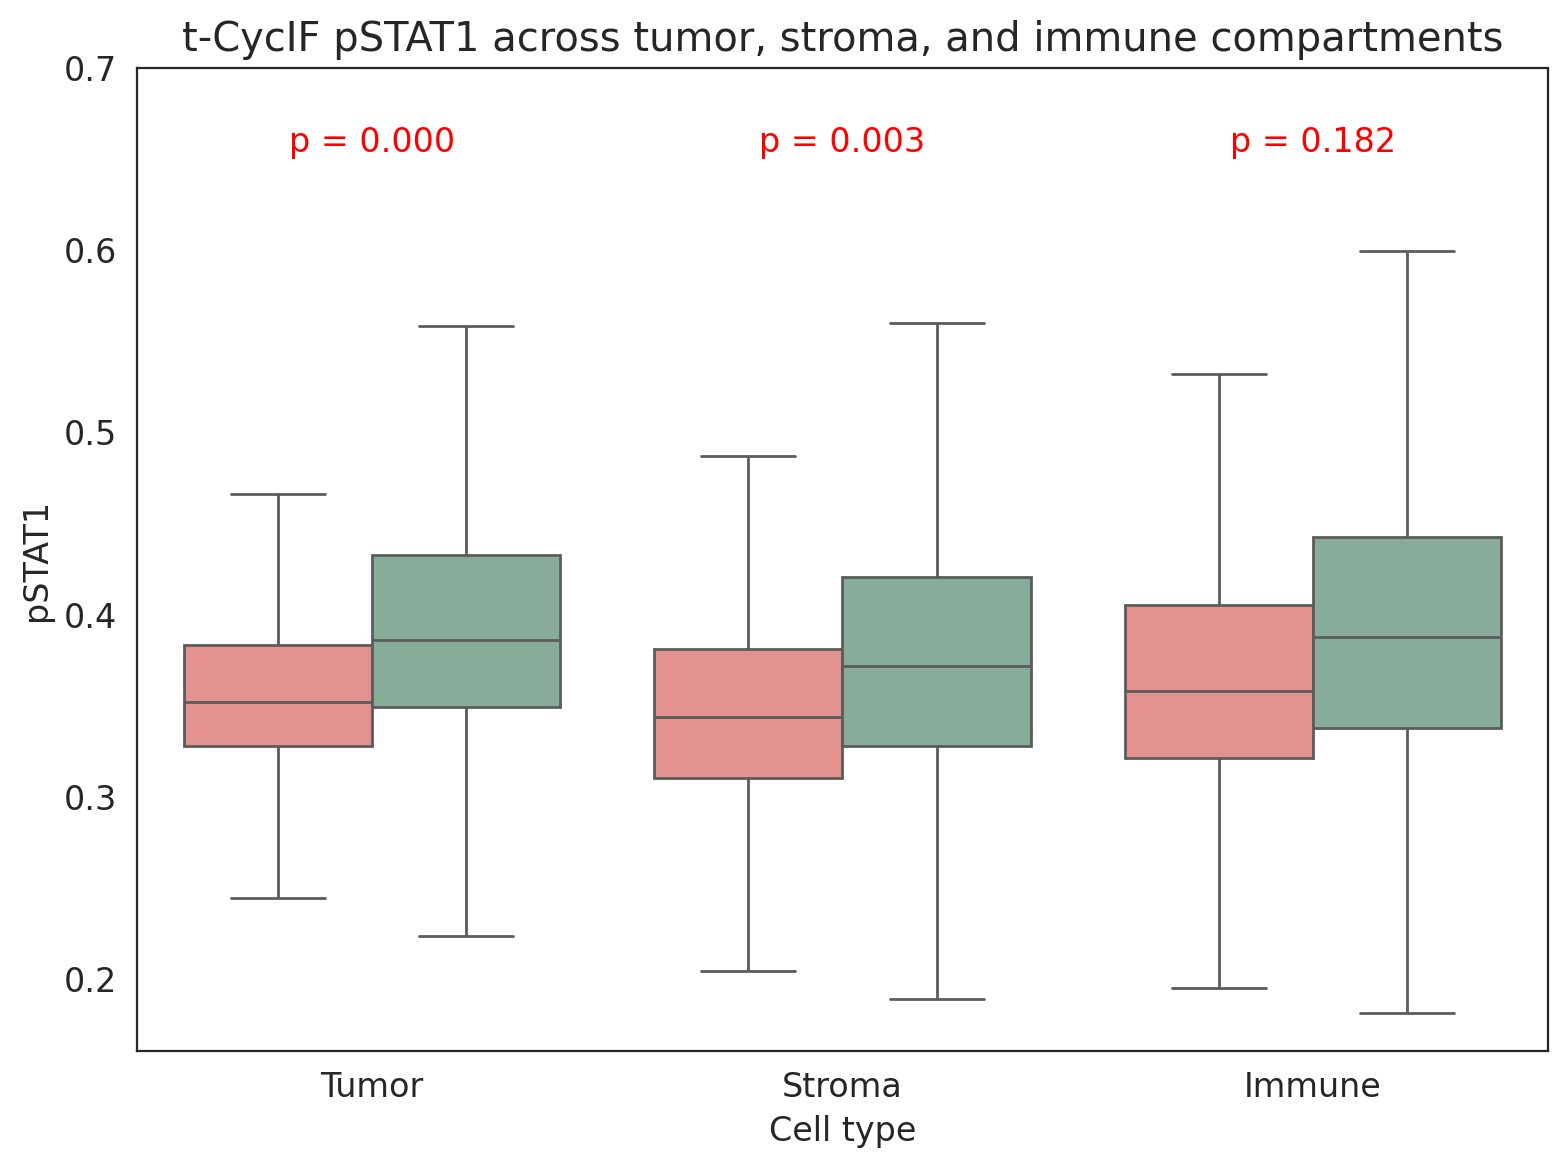

In [121]:
gee_p_values = {'Tumor': 0.000, 'Stroma': 0.003, 'Immune': 0.182}

plt.figure(figsize=(8, 6))
sns.boxplot(x='GlobalCellType2', y='pSTAT1',
            hue='status', data=cycif,
            palette=status_palette, legend=False,
            showfliers=False,
            order=['Tumor', 'Stroma', 'Immune'])

plt.title('t-CycIF pSTAT1 across tumor, stroma, and immune compartments')
plt.ylabel('pSTAT1')
plt.xlabel('Cell type')
plt.ylim(top=0.7)

for i, cell_type in enumerate(['Tumor', 'Stroma', 'Immune']):
    plt.text(i, 0.65, f'p = {gee_p_values[cell_type]:.3f}', 
             ha='center', va='bottom', color='red', fontsize=12)

plt.tight_layout()

# plt.savefig('/mnt/storageBig8/work/afenteva/ChemoRef/REVIEW1/scRNA/figures/boxplots_tcycif.pdf',
#             format='pdf', dpi=600)

plt.show()

In [122]:
# cycif.drop(columns=['Sample_code', 'yH2AX']).to_csv('/mnt/storageBig8/work/afenteva/ChemoRef/PAPER/CycIF_for_review.tsv',
#                                          sep='\t')